In [1]:
import tensorflow as tf
#import levenberg_marquardt as lm
import scipy.stats
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import seaborn as sns
from glob import glob
import xarray as xr
#import typhon as ty
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/')
print(sys.path)
from src import retrieval_dev_fcts as dev
from src import retrieval_plots as rp
# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

# use typhon ploting style
#plt.style.use(ty.plots.styles.get('typhon'))

2025-10-19 22:57:09.637629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760907429.653035 1151378 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760907429.658202 1151378 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-19 22:57:09.674587: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


['/home/u/u301032/lib/python', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python312.zip', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/lib-dynload', '', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/setuptools/_vendor', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/']
['/home/u/u301032/lib/python', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python312.zip', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/lib-dynload', '', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.

In [8]:

training_version = "_v2" #''
## LOAD teat and predicted data
IWV_test_predictions_squared=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/IWV_test_predictions_squared{training_version}.npy')
IWP_test_predictions_squared=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/IWP_test_predictions_squared{training_version}.npy')
#LWP_test_predictions_squared=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/LWP_test_predictions_squared{training_version}.npy')
LWP_test_predictions_squared=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/LWP_test_predictions_squared.npy')
CLWP_test_predictions_squared=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/CLWP_test_predictions_squared{training_version}.npy')
#test_LWP=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/test_LWP{training_version}.npy')
test_LWP=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/test_LWP.npy')
test_CLWP=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/test_CLWP{training_version}.npy')
test_IWP=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/test_IWP{training_version}.npy')
test_IWV=np.load(f'/work/um0203/u301032/master_thesis/retrieval_test_data/test_IWV{training_version}.npy')

data=[[test_IWV,IWV_test_predictions_squared],[test_CLWP,CLWP_test_predictions_squared],[test_IWP,IWP_test_predictions_squared]]
variables=['IWV','LWP','CLWP','IWP']
target_data = {
    'IWV': test_IWV,#[::100],
    'LWP': test_LWP,#[::100],
    'CLWP': test_CLWP,#[::100],
    'IWP': test_IWP,#[::100]

}
prediction_data = {
    'IWV': IWV_test_predictions_squared,#[::100],
    'LWP': LWP_test_predictions_squared,#[::100],
    'CLWP': CLWP_test_predictions_squared,#[::100],
    'IWP': IWP_test_predictions_squared,#[::100]
}

In [5]:
target_data = {
    'IWV': test_IWV[::100],
    'LWP': test_LWP[::100],
    'CLWP': test_CLWP[::100],
    'IWP': test_IWP[::100]

}
prediction_data = {
    'IWV': IWV_test_predictions_squared[::100],
    'LWP': LWP_test_predictions_squared[::100],
    'CLWP': CLWP_test_predictions_squared[::100],
    'IWP': IWP_test_predictions_squared[::100]
}

In [6]:
def plot_scatter_3_tiles(filename=None):
    fig = plt.figure(figsize=(15, 15),constrained_layout=True)

    subfigs = fig.subfigures(2, 2)
    subfigs[0,1]

    for var, subfig, title in zip(variables,subfigs.flat, ['a)','','b)','c)']):
        if subfig ==subfigs[0,1]:
            ax=subfig.subplots()
            ax.axis('off')
        else:
            if var =='IWV':
                kind='lin'
            else: kind='log'    
            dev.plot_scatter_log( target_data[var],prediction_data[var], var,kind = kind,fig=subfig)
            subfig.suptitle(' ',ha='left')
            subfig.text(0.0, 1.0, title, #transform=ax.transAxes,
                                       fontsize=16,  va='top')
    if filename:
        #plt.tight_layout()
        plt.savefig(f'/home/u/u301032/orcestra/plots/scatter_tiles_target_predictions_{filename}.png',dpi=400)
    plt.show()


In [ ]:
plot_scatter_3_tiles(filename='v3')


Bias: -0.04
RMSE: 0.87
Corr: 0.99
Bias: -0.02
RMSE: 0.31
Corr: 0.95
Bias: 0.01
RMSE: 0.34
Corr: 0.88


/tmp/ipykernel_1151378/1927643928.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f'/home/u/u301032/orcestra/plots/scatter_tiles_target_predictions_{filename}.png',dpi=400)


## Load preprocessed training data

### **Please define altitude**


In [2]:
flight_levels =[11400,12650,13000,13250,13600,13850,14450,15000	]
altitude = 14450 #from prep-for-NN-training.py script
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 

In [3]:
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
'/work/um0203/u301032/master_thesis/ML_input'
data=[]
names=[ 'IWV', 'IWP', 'LWP','cllvi','t_steps','cell_selection']
for i in range(len(names)):
    data.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_' + names[i] + '.npy'))
IWV, IWP, LWP,CLWP,t_steps,cell_selection =data
IWP=1000*IWP
LWP=1000*LWP
CLWP = 1000*CLWP
TBs_array=[]
mu_array=[]
sigma_array=[]

#for altitude in flight_levels:
#    TBs_array.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy'))
TBs=np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy')


#### Filter for unrealistic BTs missing and determine calculation of flight level


In [4]:
#filter for unrealistic BTs
 
TB_input_vector = dev.array_setup(TBs,t_steps,cell_selection)

In [5]:
# set IWP values below 1gm2 to zero #TODO check what this means in tropics eg literature, histograms Because Icon has nearly no true zeroes
IWP[IWP<1]=0.000000001
LWP[LWP<1]=0.000000001
CLWP[CLWP<1]=0.000000001


In [5]:
#FOR LOG
IWP[IWP<=10**(-9)]=10**(-9)
LWP[LWP<=10**(-9)]=10**(-9)
CLWP[CLWP<=10**(-9)]=10**(-9)

### Splitting Test and Training Data
#### Here timestepwise

In [56]:
t_steps[::3]

array(['2024-08-25T00:00:00.000000000', '2024-08-25T06:00:00.000000000',
       '2024-08-25T12:00:00.000000000', '2024-08-25T18:00:00.000000000',
       '2024-08-26T00:00:00.000000000', '2024-08-29T16:00:00.000000000',
       '2024-08-29T22:00:00.000000000', '2024-09-28T02:00:00.000000000',
       '2024-09-28T08:00:00.000000000', '2024-09-28T14:00:00.000000000',
       '2024-09-28T20:00:00.000000000'], dtype='datetime64[ns]')

In [6]:
from src import retrieval_dev_fcts as dev

In [7]:
def splitting_train_test_2(hyd,t_steps):
    slices_train, slices_validate, slices_test = dev.defining_slices_for_data_v2()
    hyd1, hyd2, hyd3 = dev.splitting_in_train_test_validate(hyd,t_steps,slices_train,slices_validate,slices_test)
    train_hyd=np.concatenate([hyd1, hyd3])
    test_hyd=hyd2
    return train_hyd, test_hyd

train_IWV,test_IWV=splitting_train_test_2(IWV,t_steps)
train_LWP,test_LWP=splitting_train_test_2(LWP,t_steps)
train_CLWP,test_CLWP=splitting_train_test_2(CLWP,t_steps)
train_IWP,test_IWP=splitting_train_test_2(IWP,t_steps)


In [8]:
# Defining slices
slices_train, slices_validate, slices_test = dev.defining_slices_for_data_v2() # customized for current runs

# Hydrometeor and TBs into training and testing sets
## Möglicherweise train, test and validate als jeweils 3 elementiger array
#train_TB, test_TB, validate_TB = dev.splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
#train_IWV, test_IWV, validate_IWV = dev.splitting_in_train_test_validate(IWV,t_steps,slices_train,slices_validate,slices_test)
#train_LWP, test_LWP, validate_LWP = dev.splitting_in_train_test_validate(LWP,t_steps,slices_train,slices_validate,slices_test)
#train_CLWP, test_CLWP, validate_CLWP = dev.splitting_in_train_test_validate(CLWP,t_steps,slices_train,slices_validate,slices_test)
#train_IWP, test_IWP, validate_IWP = dev.splitting_in_train_test_validate(IWP,t_steps,slices_train,slices_validate,slices_test)
TB1, TB2, TB3 = dev.splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
IWV1, IWV2, IWV3 = dev.splitting_in_train_test_validate(IWV,t_steps,slices_train,slices_validate,slices_test)
LWP1, LWP2, LWP3 = dev.splitting_in_train_test_validate(LWP,t_steps,slices_train,slices_validate,slices_test)
CLWP1, CLWP2, CLWP3 = dev.splitting_in_train_test_validate(CLWP,t_steps,slices_train,slices_validate,slices_test)
IWP1, IWP2, IWP3 = dev.splitting_in_train_test_validate(IWP,t_steps,slices_train,slices_validate,slices_test)
train_TB=np.concatenate([TB1,TB3])
train_IWV=np.concatenate([IWV1, IWV3])
train_IWP=np.concatenate([IWP1, IWP3])
train_LWP=np.concatenate([LWP1, LWP3])
train_CLWP=np.concatenate([CLWP1, CLWP3])
test_TB=TB2
test_IWV=IWV2
test_IWP=IWP2
test_LWP=LWP2
test_CLWP=CLWP2

In [10]:
print('IWV',IWV.max(),train_IWV.max(),test_IWV.max())
print('IWV',IWV.min(),train_IWV.min(),test_IWV.min())
print('LWP',CLWP.max(),train_CLWP.max(),test_CLWP.max())
print('IWP',IWP.max(),train_IWP.max(),test_IWP.max())

IWV 77.88089 77.88089 77.67199
IWV 14.903346 14.903346 16.056953
LWP 12759.026 12759.026 9337.333
IWP 24830.377 22425.625 24830.377


In [54]:

print('IWP:',IWP.mean(),np.median(IWP))
print('IWP:',np.sqrt(IWP).mean(),np.median(np.sqrt(IWP)))
print('IWP:',np.log10(IWP).mean(),np.median(np.log10(IWP)))

IWP: 48.19417 0.12944034
IWP: 2.232877 0.35977817
IWP: -1.6356406 -0.8879304


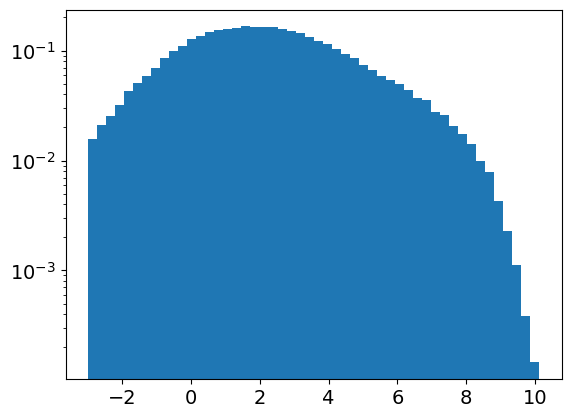

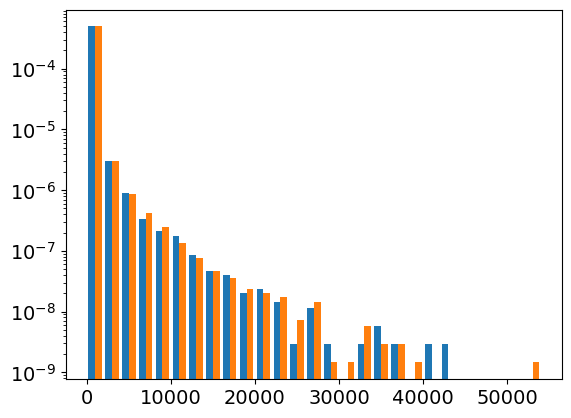

In [260]:
#optional random draw
import random
draw=np.arange(len(IWP))
random.shuffle(draw)

draw_test = draw[:172161]
draw_train = draw[172161:]

plt.hist([np.log(IWP[draw_cloud]-0.95)], bins =50,density=True,log=True)
plt.show()
plt.hist([LWP[draw_test], LWP[draw_train]], bins =np.arange(-2,55000,2000),density=True,log=True)
plt.show()

## Distribution of training and testing datasets

In [245]:
draw=np.arange(len(IWP))
draw_cloud = draw[IWP>1]
draw_cloud

array([     0,      1,      2, ..., 516460, 516462, 516464],
      shape=(157204,))

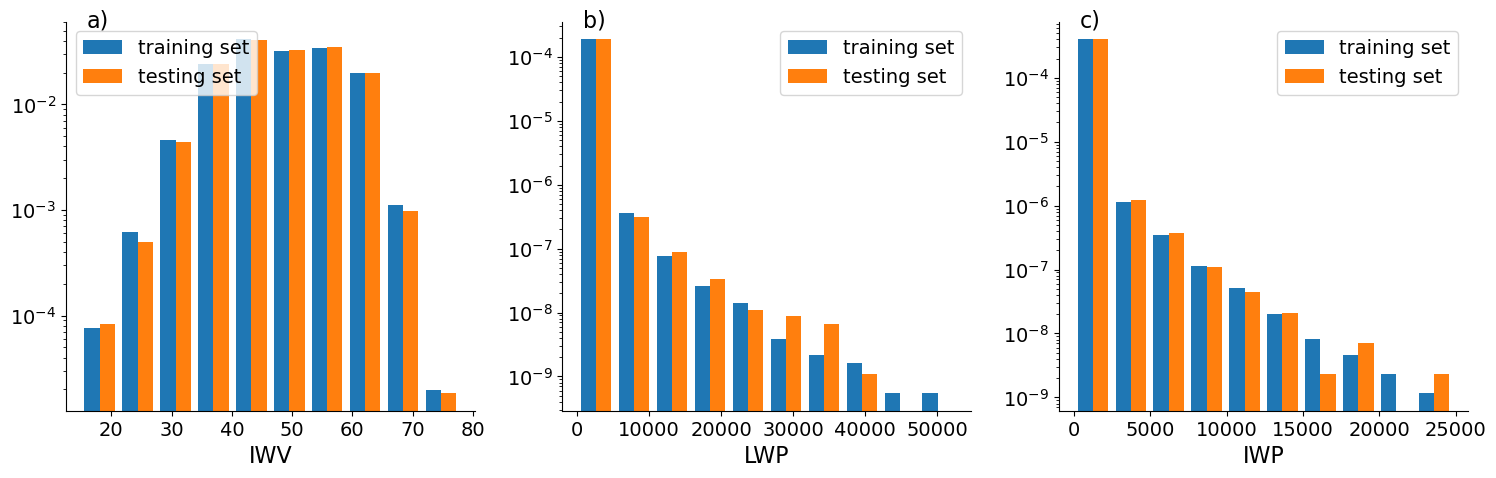

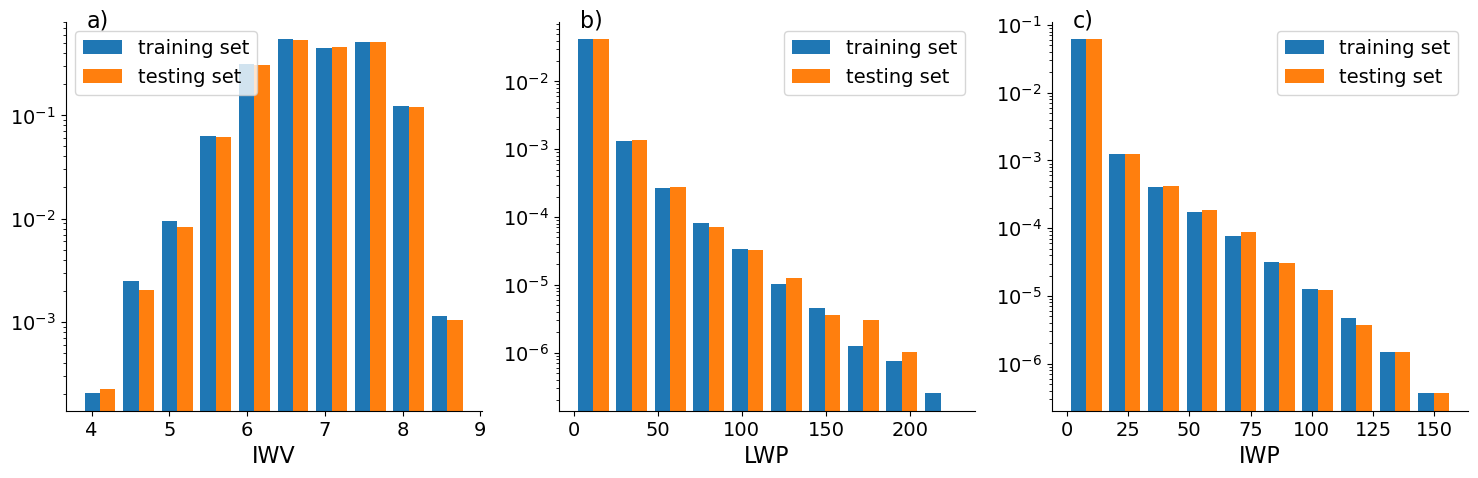

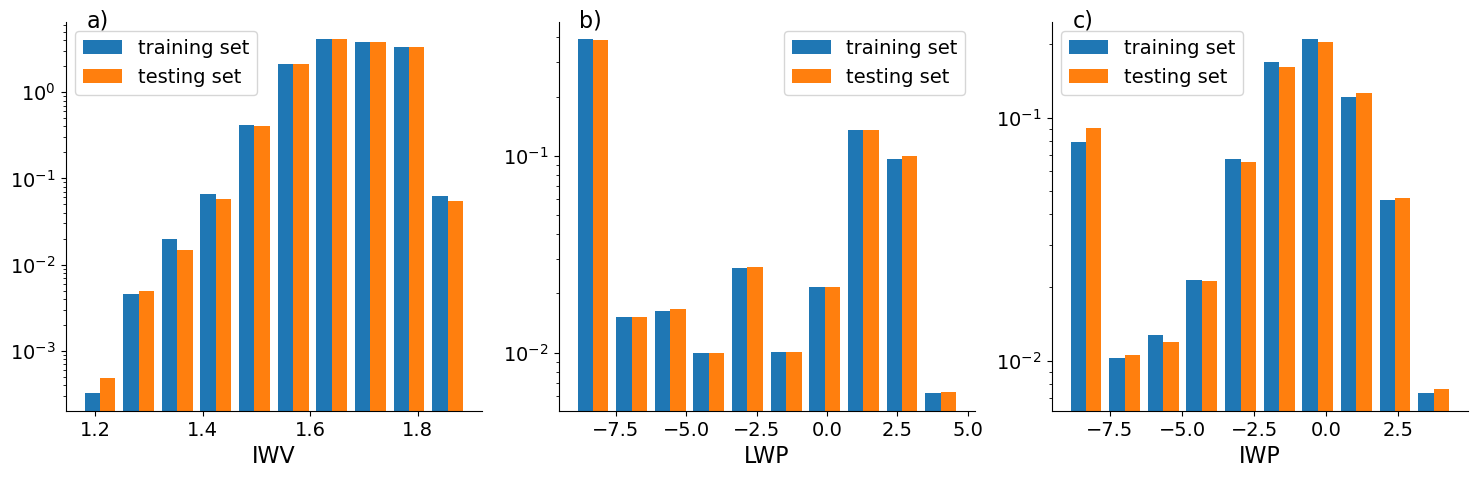

In [8]:

#train_array = [train_IWV, train_LWP, train_IWP] # maybe useful later?
#test_array = [test_IWV, test_LWP, test_IWP]
data_log = [[np.log10(train_IWV), np.log10(test_IWV)],[np.log10(train_LWP), np.log10(test_LWP)],[np.log10(train_IWP), np.log10(test_IWP)]] #[train_CLWP, test_CLWP]]#
data_sqrt = [[np.sqrt(train_IWV), np.sqrt(test_IWV)],[np.sqrt(train_LWP), np.sqrt(test_LWP)],[np.sqrt(train_IWP), np.sqrt(test_IWP)]] #[train_CLWP, test_CLWP]]#
data = [[(train_IWV), (test_IWV)],[(train_LWP), (test_LWP)],[(train_IWP), (test_IWP)]] #[train_CLWP, test_CLWP]]#


label = ['training set','testing set']
plot='hist'

dev.plot_3_by_1(data, 'hist', label)
dev.plot_3_by_1(data_sqrt, 'hist', label)
dev.plot_3_by_1(data_log, 'hist', label)

(-1121.28124999895, 1000.0)

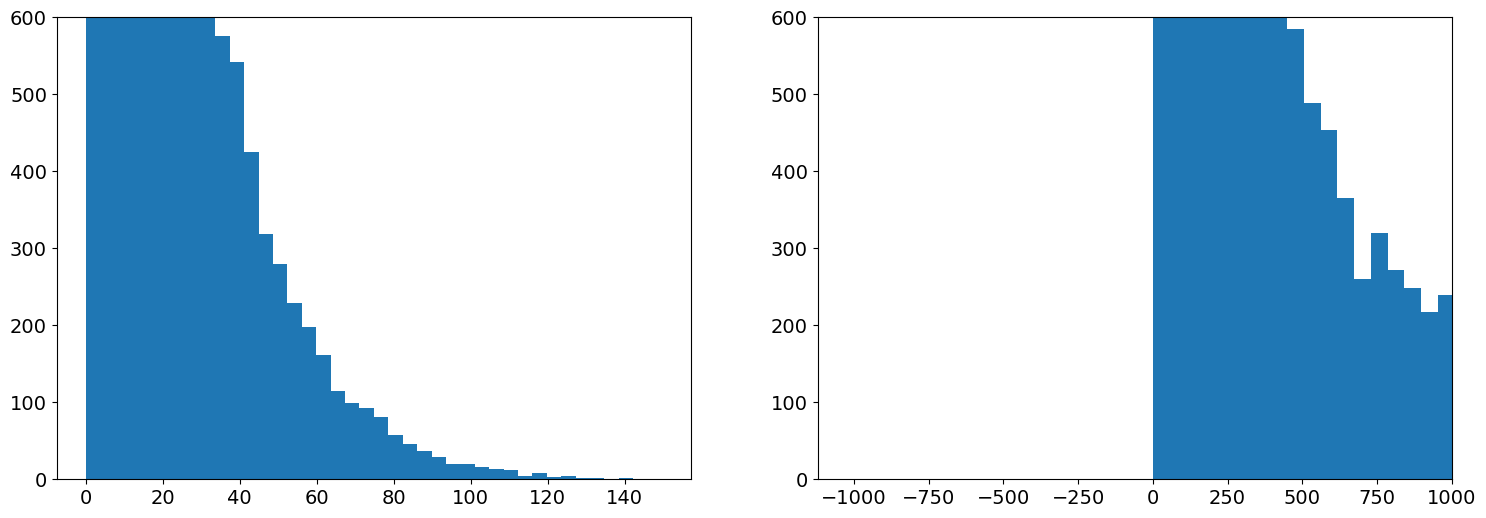

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(18, 6))
ylim =600  #max war 300,000
ax1.hist([np.sqrt(train_IWP)],bins=40)
ax1.set_ylim(top=ylim)
#ax1.set_xscale('log')
#ax1.set_yscale('log')
#ax2.set_yscale('log')
ax2.hist([(train_IWP)],bins=400)
ax2.set_ylim(top=ylim)
ax2.set_xlim(right=1000)
#ax2.set_xscale('log')

### Standardizing Input
##### standardize all TBs along their respective channel as a normal distribution with mean 0 and std of 1

In [32]:
TBs_train_scaled, mu_train, sigma_train = dev.standardize_nn_training_data(train_TB) 
TBs_test_scaled = dev.standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 
#TBs_validate_scaled = dev.standardize_nn_input_data_v2(validate_TB,mu=mu_train,sigma=sigma_train)

## IWP
### Cross validation

In [8]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.0001

EPOCHS = 40#1000
BATCH_SIZE = 100#50

In [30]:
TB_input_vector.shape[1]

24

In [37]:

#dnn_model_iwp = crossvalidation(train_TB,train_IWP)

### Choosing value to train : IWP, LWP or IWV
## IWP

In [13]:

variable= "IWP" # "LWP" # "IWV" #




#### Definition of network

In [77]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32
NR_of_NEURONS_L2 = 16
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanAbsolutePercentageError()#tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 50 #1000
BATCH_SIZE = 50

#### Loop over all altitudes: Compilation , Training and saving of each Network


(array([389618.,   1128.,    333.,    110.,     47.,     23.,      6.,
             7.,      2.,      1.]),
 array([    0.   ,  2483.038,  4966.075,  7449.113,  9932.15 , 12415.188,
        14898.226, 17381.264, 19864.301, 22347.338, 24830.377]),
 <BarContainer object of 10 artists>)

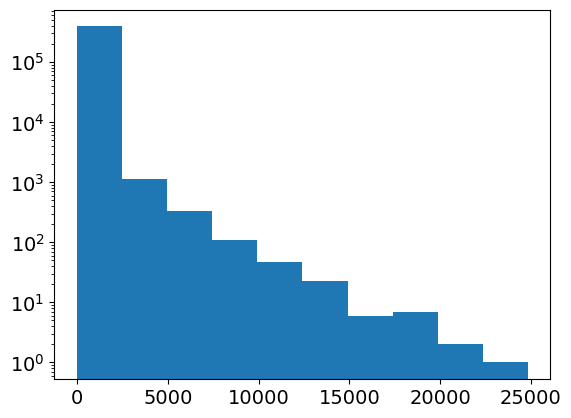

In [41]:
#xt, _=scipy.stats.boxcox(train_IWP)
plt.hist(train_IWP,log=True)

In [25]:
np.array([IWP,LWP,IWV]).T
#TBs_train_scaled[::10]
#TB_input_vector

array([[ 28.427,  23.43 ,  57.764],
       [114.83 , 248.757,  59.085],
       [ 61.231,  35.77 ,  57.431],
       ...,
       [  0.004,   0.008,  41.388],
       [  0.012,   0.   ,  42.575],
       [  0.045,   0.003,  42.161]], shape=(516483, 3), dtype=float32)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_8 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 932 (3.64 KB)

 Trainable params: 932 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

CPU times: user 5min 25s, sys: 18.1 s, total: 5min 44s
Wall time: 4min 11s


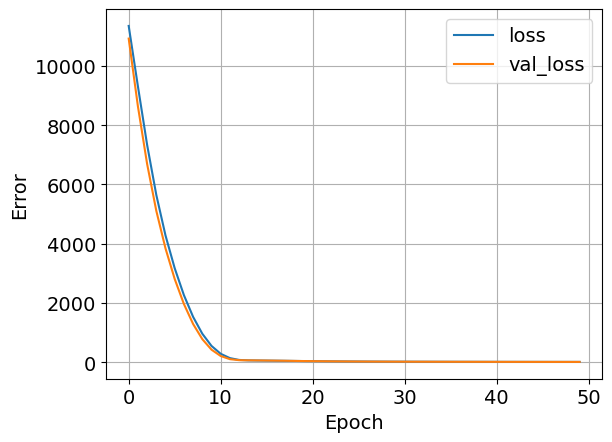

In [56]:
%%time

def define_and_compile_nn(TBs_train, NR_of_NEURONS_L1, NR_of_NEURONS_L2, BIAS_INIT, WEIGHT_INIT, ACTIVATION_HL, ACTIVATION_OP, LOSS_FUNCTION, LEARNING_RATE):
    """
    # define & compile nn-model for lwp with specified settings
    # * 1 input layer (24 neurons) 
    # * 1 hidden layer (64 neurons)
    # * 1 output layer (1 neuron)
    """    
    dnn_model = tf.keras.Sequential([
        tf.keras.layers.Dropout(rate=0.05, input_shape=(TBs_train.shape[1],)),
        tf.keras.layers.Dense(NR_of_NEURONS_L1,
                              input_shape=(TBs_train.shape[1],),
                              bias_initializer=BIAS_INIT,
                              kernel_initializer=WEIGHT_INIT,
                              kernel_regularizer="l2",
                              activation=ACTIVATION_HL,
                             ),
        
       # tf.keras.layers.Dense(NR_of_NEURONS_L2,
       #                       input_shape=NR_of_NEURONS_L1,
       #                       bias_initializer=BIAS_INIT,
       #                       kernel_initializer=WEIGHT_INIT,
       #                       kernel_regularizer="l2",
       #                       activation=ACTIVATION_HL,
       #                      ),
       # tf.keras.layers.Dropout(rate=0.05, input_shape=NR_of_NEURONS_L2),
       # 
        tf.keras.layers.Dense(4,
                              activation=ACTIVATION_OP)])
    
    dnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                          loss=LOSS_FUNCTION,
                         )
    
    dnn_model.summary()
    return dnn_model


def train_NN(dnn_model, TBs_train_scaled, train_hyd, EPOCHS, BATCH_SIZE, plotting = False):
    history = dnn_model.fit(
        TBs_train_scaled, np.sqrt(train_hyd),
        validation_split=0.2,
        #validation_data=(TBs_validate_scaled,validate_hyd),#new
        verbose=0,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)]
    )
    if plotting:
        plt.plot(history.history['loss'], label='loss')
        plt.plot(history.history['val_loss'], label='val_loss')
        #plt.ylim(0,40)
        plt.xlabel('Epoch')
        plt.ylabel('Error')
        plt.grid(True)
        plt.legend()
        
        #if saving:
        #plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_training_error_loss_24-32-1.jpg',bbox_inches='tight',dpi=200)
    return dnn_model


dnn_model_all = define_and_compile_nn(TBs_train_scaled, NR_of_NEURONS_L1, NR_of_NEURONS_L2, BIAS_INIT, WEIGHT_INIT, ACTIVATION_HL, ACTIVATION_OP, LOSS_FUNCTION, LEARNING_RATE)
# now with log #np.array([IWP,LWP,IWV]).T
dnn_model_all = train_NN(dnn_model_all, TBs_train_scaled, np.array([train_IWP,train_LWP,train_CLWP,1000*train_IWV]).T, EPOCHS, BATCH_SIZE, plotting = True)

In [62]:
all_test_predictions = dnn_model_all.predict(TBs_test_scaled)
all_test_predictions

5381/5381 ━━━━━━━━━━━━━━━━━━━━ 2s 424us/step


array([[  2.589,   1.976,   2.112, 242.286],
       [  2.806,   0.87 ,   0.973, 242.078],
       [  3.069,   1.674,   1.815, 243.35 ],
       ...,
       [ -1.426,  23.525,  23.165, 203.539],
       [  0.785,   2.555,   2.577, 203.461],
       [  0.549,   0.657,   0.627, 203.145]],
      shape=(172161, 4), dtype=float32)

Negative predictions: 5.37 %
Bias before cliping:  1.28
Bias after cliping:  1.3


(array([[171586.,    575.,      0.,      0.,      0.,      0.,      0.,
              0.,      0.,      0.],
        [171402.,    521.,    158.,     47.,     19.,      9.,      1.,
              3.,      0.,      1.]]),
 array([    0.   ,  2483.038,  4966.075,  7449.113,  9932.15 , 12415.188,
        14898.226, 17381.264, 19864.301, 22347.338, 24830.377]),
 <a list of 2 BarContainer objects>)

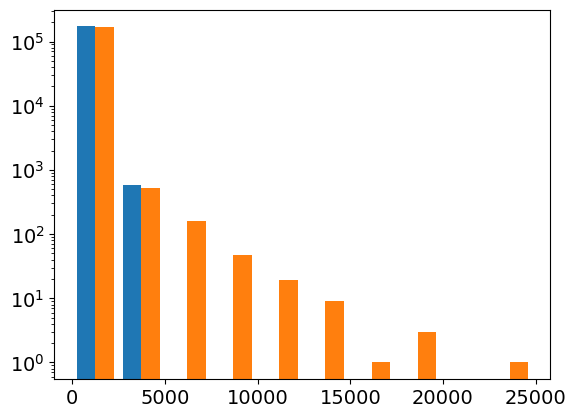

In [68]:
IWP_test_predictions = all_test_predictions[:,0]
IWP_test_predictions_cliped = dev.clip_nn_output(IWP_test_predictions,truth=True)
IWP_test_predictions_squared = (IWP_test_predictions_cliped)**2#**2
plt.hist([IWP_test_predictions_squared,test_IWP],log=True)

Negative predictions: 0.0 %
Bias before cliping:  218.36
Bias after cliping:  218.36


(array([[  103.,   438.,  6426., 27194., 45076., 32825., 38531., 20752.,
           816.,     0.],
        [  129.,   702.,  6224., 28838., 43457., 34205., 37315., 20246.,
          1024.,    21.]]),
 array([16.057, 22.218, 28.38 , 34.541, 40.703, 46.864, 53.026, 59.187,
        65.349, 71.51 , 77.672]),
 <a list of 2 BarContainer objects>)

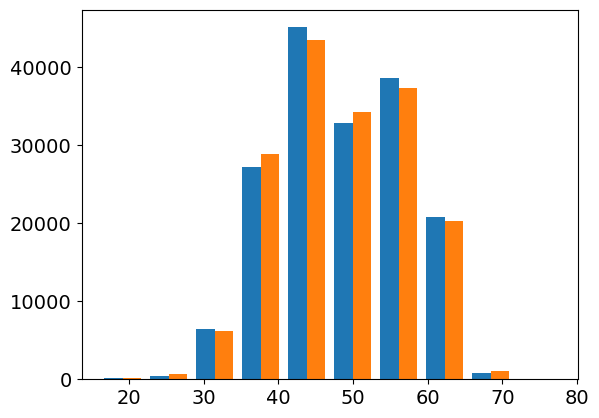

In [66]:
IWV_test_predictions = all_test_predictions[:,3]
IWV_test_predictions_cliped = dev.clip_nn_output(IWV_test_predictions,truth=True)
IWV_test_predictions_squared = (IWV_test_predictions_cliped)**2/1000#**2
plt.hist([IWV_test_predictions_squared,test_IWV])

altitude used for training: 14450


/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_10 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

CPU times: user 5min 36s, sys: 18.7 s, total: 5min 55s
Wall time: 4min 16s


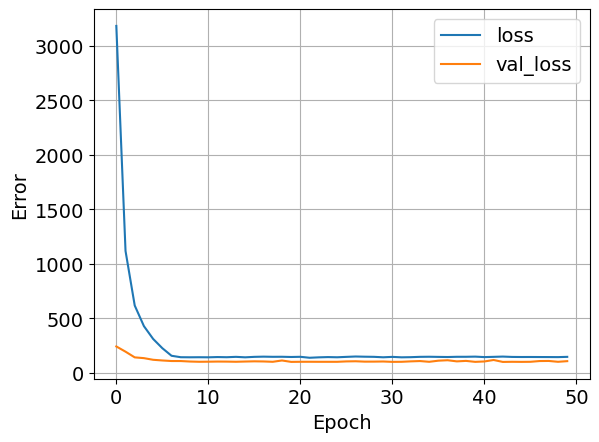

In [78]:
%%time

# information on loss and val loss: https://machinelearningmastery.com/learning-curves-for-diagnosing-machine-learning-model-performance/
#for altitude in flight_levels:
print("altitude used for training:", altitude)

 # define & compile nn-model for lwp with specified settings
dnn_model_iwp = dev.define_and_compile_nn(TBs_train_scaled, NR_of_NEURONS_L1, BIAS_INIT, WEIGHT_INIT, ACTIVATION_HL, ACTIVATION_OP, LOSS_FUNCTION, LEARNING_RATE)

dnn_model_iwp = dev.train_NN(dnn_model_iwp, TBs_train_scaled, train_IWP, EPOCHS, BATCH_SIZE, plotting = True)

#dnn_model_iwp.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_ + {training_version}.keras')
    #save mu and sigma
    #np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + training_version + '_v1_'+ str(altitude) +'m.npy',mu_train)
    #np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + training_version + '_v1_'+ str(altitude) +'m.npy',sigma_train)
    #if altitude == 14450:
    #    TBs_train=train_TB
    #    train_hyd =train_IWP #Hyd to train
    #    test_hyd

In [3]:
### LOAD MODEL
variable='IWP'
#dnn_model_iwp.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_v2.keras')
#altitude = 14450 #from prep-for-NN-training.py script
path=(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/')

dnn_model_iwp = tf.keras.models.load_model(path+f'dnn_model_{variable}_24-32-1_reg_{altitude}m_v2.keras',compile=False)
test_IWP=np.load(path+f'dnn_model_{variable}_24-32-1_reg_14450m_v2_test_{variable}.npy')
TBs_test_scaled=np.load(path+f'dnn_model_{variable}_24-32-1_reg_14450m_v2_test_TB_scaled.npy')

2025-10-02 20:06:36.919534: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### NN-IWP performance on PAMTRA test dataset

In [4]:
# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
IWP_test_predictions_cliped = dev.clip_nn_output(IWP_test_predictions,truth=True)
# retransform neural network predictions from sqrt to linear LWP values
IWP_test_predictions_squared = IWP_test_predictions_cliped**2


5381/5381 ━━━━━━━━━━━━━━━━━━━━ 2s 369us/step
Negative predictions: 14.02 %
Bias before cliping:  1.21
Bias after cliping:  1.24


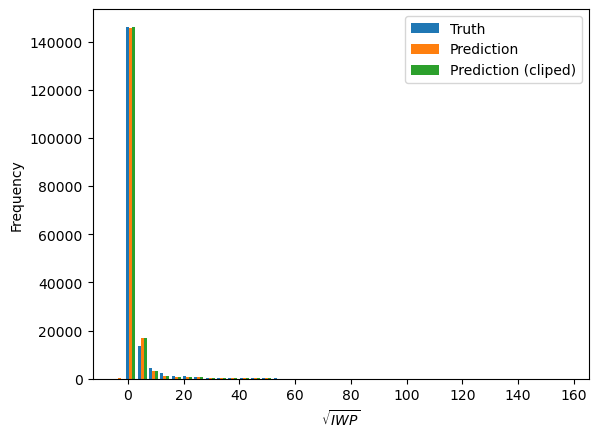

In [5]:
#plot histograms of comparison of truth, prediction and clipped prediciton
dev.plot_truth_prediction_sqrt(test_IWP, IWP_test_predictions, IWP_test_predictions_cliped, variable)

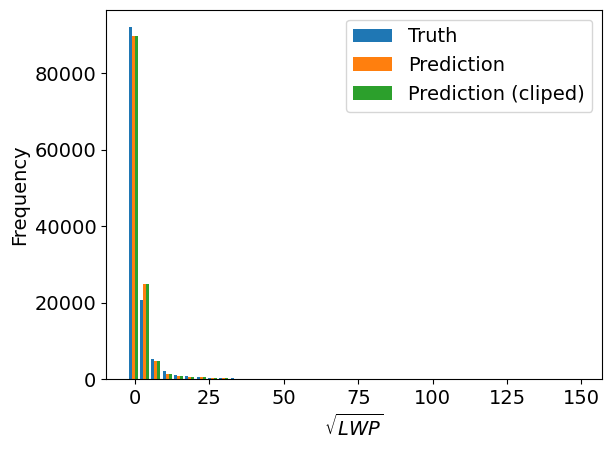

In [15]:
#plot histograms of comparison of truth, prediction and clipped prediciton
dev.plot_truth_prediction_sqrt(test_IWP, IWP_test_predictions, IWP_test_predictions_cliped, variable)


bias:  -4.35  corr:  0.97  rmse:  85.85


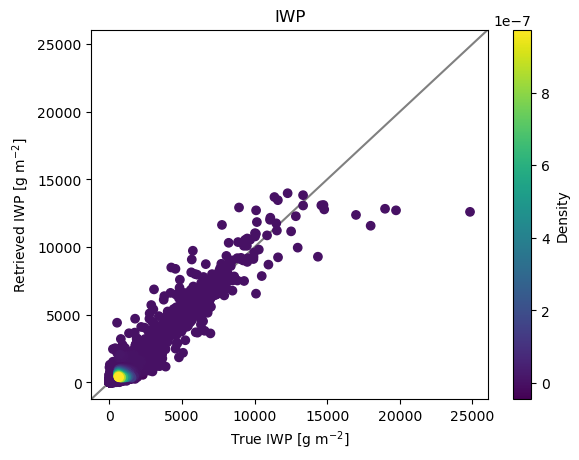

In [6]:
variable='IWP'
dev.scatter_hyd(test_IWP, IWP_test_predictions_squared, variable)

bias:  -4.97  corr:  0.98  rmse:  89.34


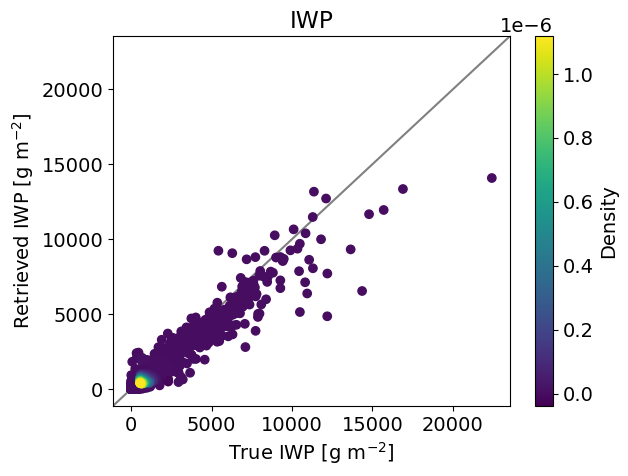

In [16]:
dev.scatter_hyd(test_IWP, IWP_test_predictions_squared, variable)

In [107]:
#np.logspace(10**0,4,0.1)
test_IWP[::100]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1253,), dtype=float32)

Bias: 0.01
RMSE: 0.33
Corr: 0.89
CPU times: user 2.4 s, sys: 151 ms, total: 2.55 s
Wall time: 380 ms


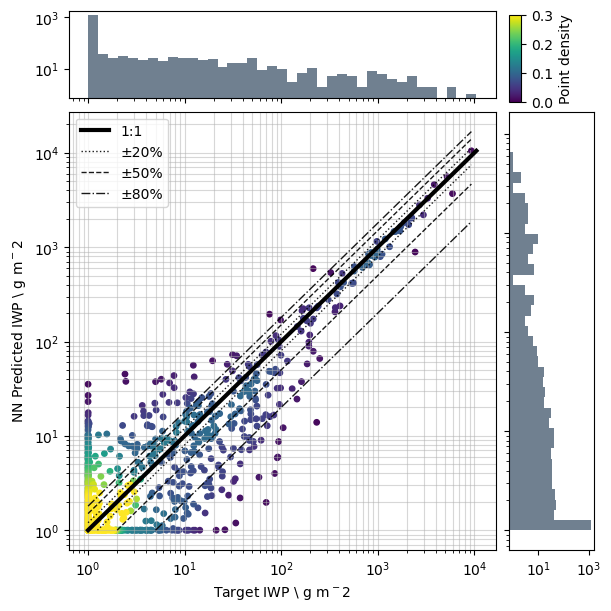

In [7]:
%%time
#plot_scatter_log(test_IWP, IWP_test_predictions_squared, variable ='IWP', kind = 'log',plotname='new_run') #'v2'
#dev.plot_scatter_log(test_IWP[::100], IWP_test_predictions_squared[::100], variable ='IWP', kind = 'log')

Bias: -0.01
RMSE: 0.33
Corr: 0.89
CPU times: user 3min 58s, sys: 211 ms, total: 3min 58s
Wall time: 3min 58s


/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


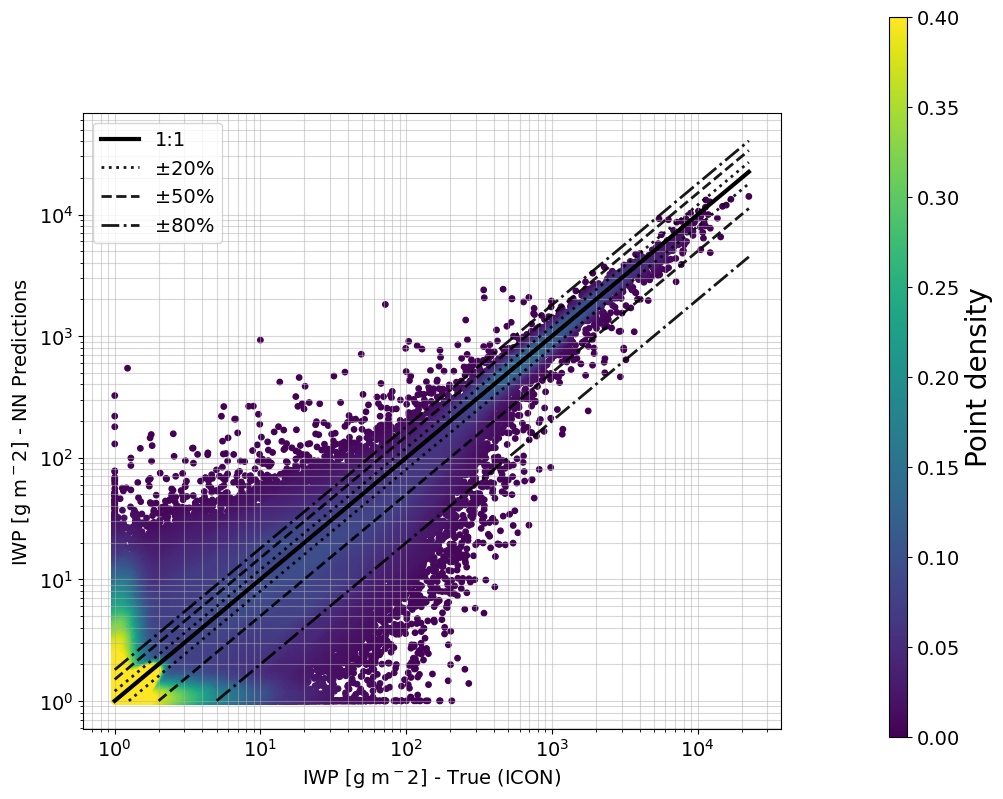

In [17]:
%%time
dev.plot_scatter_log(test_IWP, IWP_test_predictions_squared, variable ='IWP', kind = 'log')

In [75]:
def plot_scatter_log_v2(hyd_test,hyd_test_predictions_squared, variable, kind = 'log'):
           
    if kind == 'log':
        
        hyd_test_log = hyd_test.copy()
        hyd_test_log[hyd_test_log==0] = 10**(-16)
        #hyd_test_log[hyd_test_log<1] = np.nan
        hyd_test_predictions_squared_log = hyd_test_predictions_squared.copy()
        hyd_test_predictions_squared_log[hyd_test_predictions_squared_log==0] = 10**(-16)
        #hyd_test_predictions_squared_log[hyd_test_predictions_squared_log<1] = np.nan
        
        a = np.log10(hyd_test_log)
        b = np.log10(hyd_test_predictions_squared_log)
        
        #a[a<0.] = 0
        #b[b<0.] = 0
        
        #a[a<0.] = np.nan
        #b[b<0.] = np.nan
        
        #a = hyd_test.copy()
        #b = hyd_test_predictions_squared.copy()
        
        #a[a<1.] = 0.
        #b[b<1.] = 0.
        
        
    maxval = max(np.nanmax(a),np.nanmax(b))
        
    a[a<0.] = 0
    b[b<0.] = 0
    
    #f, ax = plt.subplots()
    
    #sns.set(color_codes=True)
    
    jp = sns.jointplot(x = a, y = b,
                       kind = "hist", data = None, cmap='viridis',vmin=0, vmax=60, height=8,joint_kws=dict(bins=80))
    jp.ax_joint.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    #jp.ax_joint.plot(iwp_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
    #jp.ax_joint.plot(iwp_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)
    #jp.ax_joint.plot(iwp_true,RE_50_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±50%')
    #jp.ax_joint.plot(iwp_true,RE_50_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
    #jp.ax_joint.plot(iwp_true,RE_100_plus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9,label='±100%')
    #jp.ax_joint.plot(iwp_true,RE_100_minus,linewidth=2,linestyle='dashdot',color='black',alpha=0.9)
    #jp.ax_joint.set_xlim(0,maxval)
    #jp.ax_joint.set_ylim(0,maxval)
    #jp.ax_joint.set_xscale('log')
    #jp.ax_joint.set_yscale('log')
    jp.ax_joint.plot(np.arange(0,4.5),np.arange(0,4.5),linewidth=3,linestyle='dashed',color='darkred',alpha=0.5)
    jp.ax_joint.set_xlabel(f'True {variable}'+' [g m$^{-2}$]')
    jp.ax_joint.set_ylabel(f'Retrieved {variable}'+' [g m$^{-2}$]')
    #plt.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=2,color='black',alpha=0.5)
    #plt.xscale('log')
    #plt.yscale('log')

In [39]:
IWP_test_predictions_squared

array([0.076, 1.034, 0.144, ..., 0.   , 0.446, 0.399],
      shape=(125208,), dtype=float32)

/tmp/ipykernel_4179138/1818789520.py:13: RuntimeWarning: invalid value encountered in log10
  b = np.log10(hyd_test_predictions_squared_log)


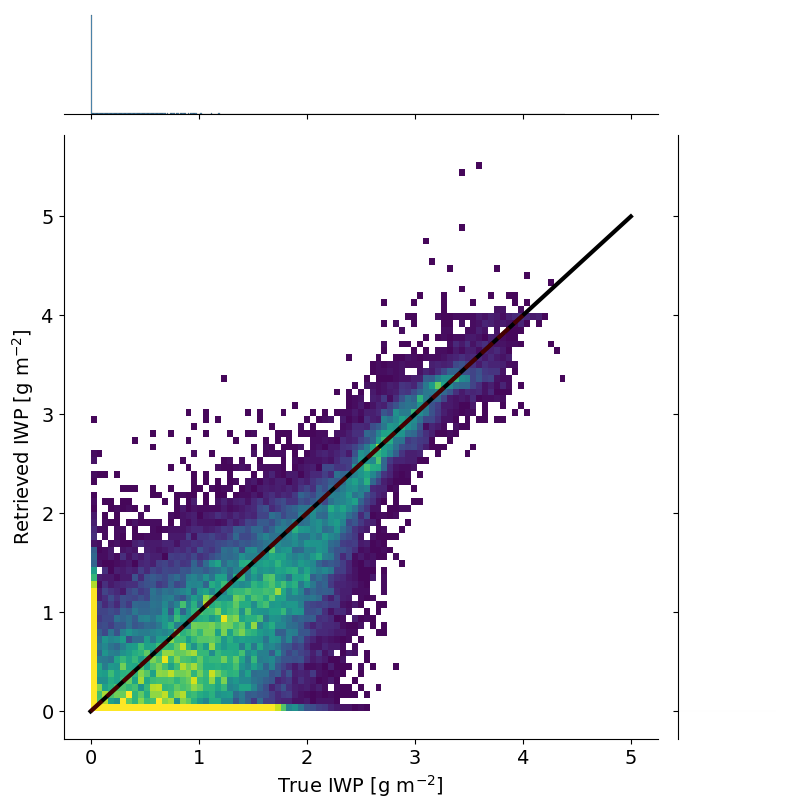

In [112]:
plot_scatter_log_v2(test_IWP, IWP_test_predictions_creative, variable='IWP')

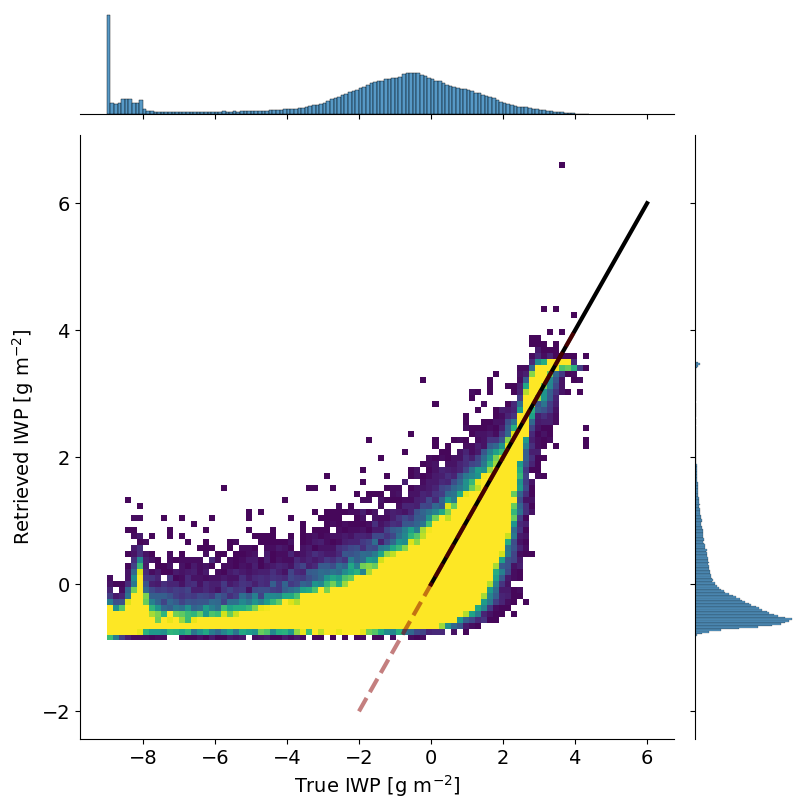

In [99]:
#LOG 
plot_scatter_log_v2(test_IWP, IWP_test_predictions_creative, variable='IWP')
# Unterschiede überlegen!

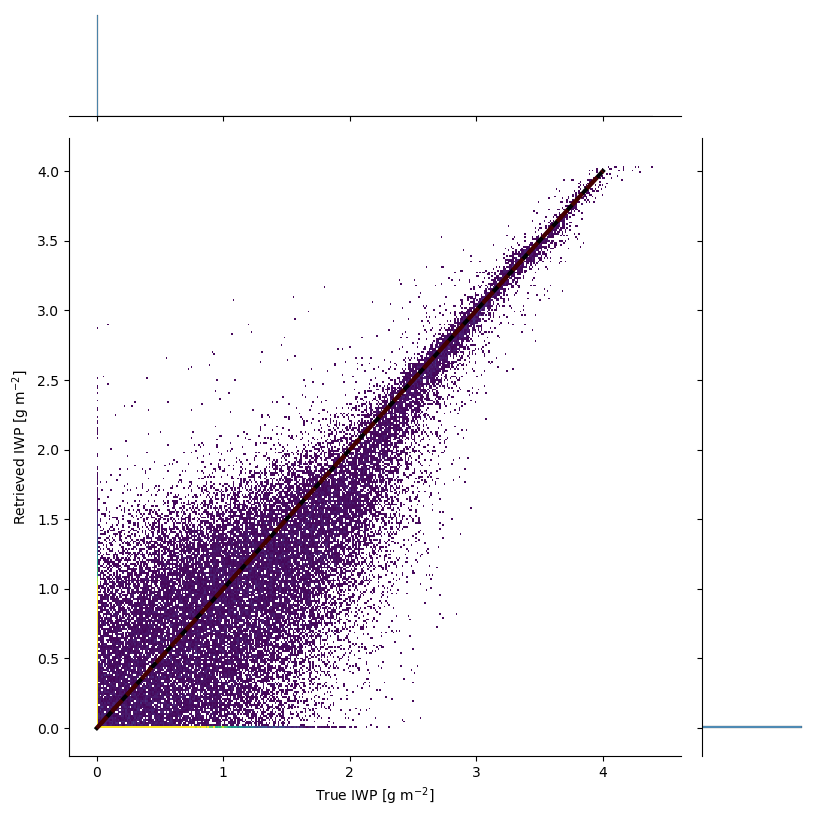

In [19]:
dev.plot_scatter_log_v2(test_IWP, IWP_test_predictions_squared, variable='IWP')

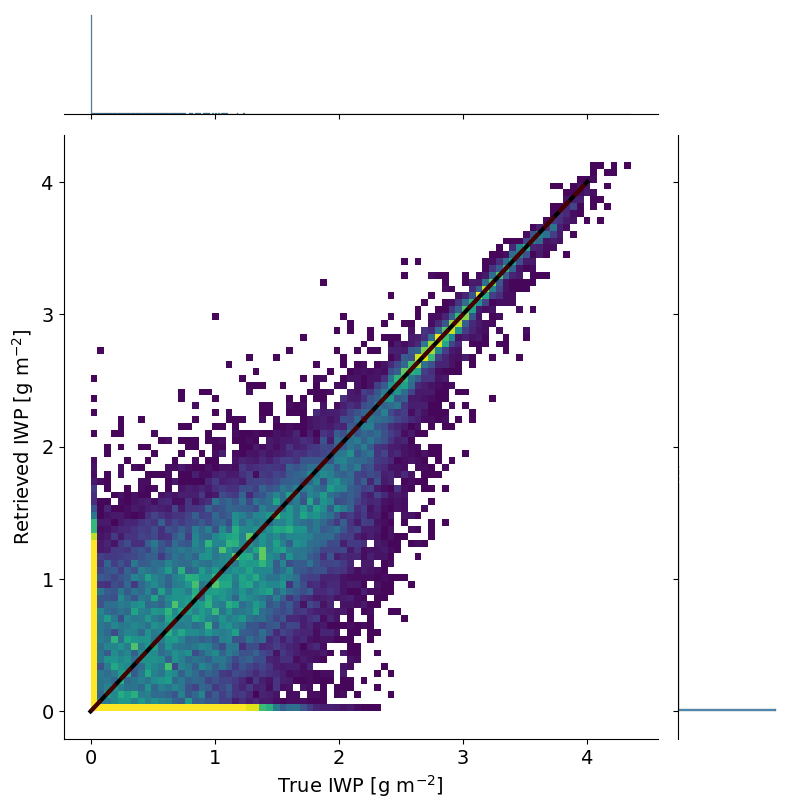

In [32]:
plot_scatter_log_v2(test_IWP, IWP_test_predictions_squared, variable='IWP')
# Unterschiede überlegen!

In [330]:
np.log10(10**(-9))

np.float64(-9.0)

(array([124196.,    581.,    177.,     93.,     81.,     30.,     17.,
            16.,     14.,      3.]),
 array([    0.   ,  1311.691,  2623.382,  3935.073,  5246.765,  6558.456,
         7870.147,  9181.838, 10493.529, 11805.221, 13116.911]),
 <BarContainer object of 10 artists>)

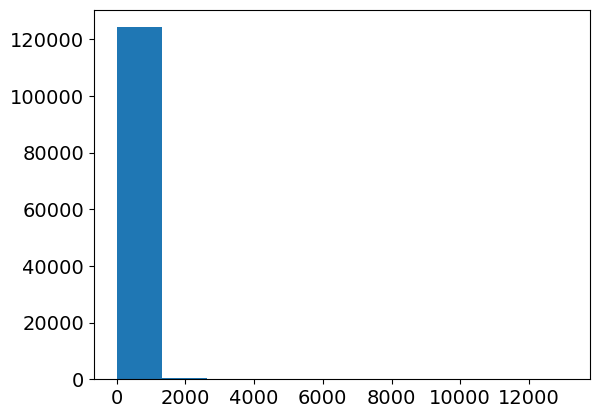

In [341]:
plt.hist(IWP_test_predictions_squared)#,bins=np.linspace(-200,60,50))

In [14]:
dev.plot_NN_error_v4(test_IWP,IWP_test_predictions_squared,variable='IWP')#,filename='log')

NameError: name 'plot_NN_error_v4' is not defined

12189
8856
7883
7186
6289
5119
3475
2091
1301
1164
1293
953
789
660
300
146


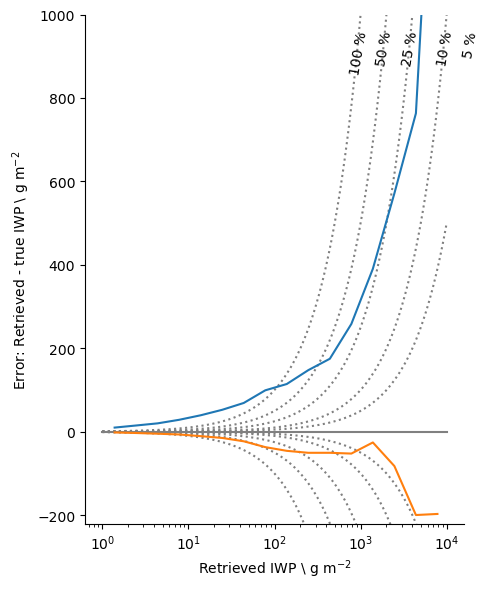

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [  -1.703   -3.056   -4.747   -6.574  -10.574  -14.924  -22.923  -36.913
  -45.784  -50.5    -50.481  -52.35   -25.705  -82.314 -199.638 -197.065]


In [21]:
#bin_centers,b_bias=plot_NN_error_v2(test_IWP,IWP_test_predictions_squared,variable)#,filename='log')
plot_NN_error_v4(test_IWP,IWP_test_predictions_squared,variable)#,filename='log')

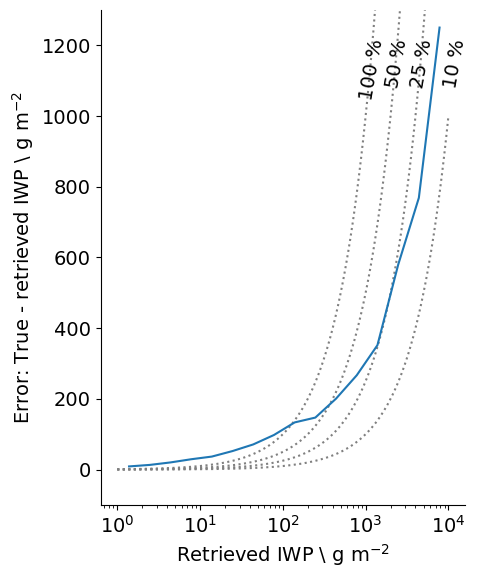

In [401]:
plot_NN_error_v2(test_IWP,IWP_test_predictions_squared,variable)#,filename='log')

0 0
0 0
0 0
0 0


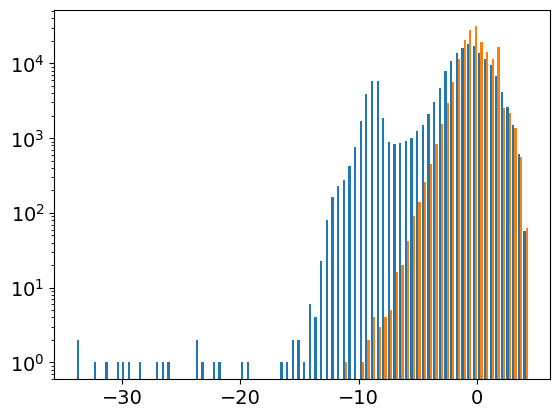

[9.338   nan 8.847 7.721 8.734 5.021 6.508 6.856 6.365 4.268 4.838 5.442
 5.239 4.386 3.937 3.551 3.492 3.398 3.822 3.72  3.617 3.515 3.581 3.541
 3.672 3.655 3.724 3.992 4.063 4.171 3.972 4.14  4.128 3.975 3.915 3.879
 3.838 3.461 2.697 2.314 2.095 1.92  1.731 1.319 1.042 0.768 0.636 7.117
 0.375 0.25  0.187 0.124 0.154 0.107 0.096 0.073] [-9.338    nan -8.847 -7.721 -8.734 -2.315 -6.486 -6.856 -6.059 -4.171
 -2.828 -4.588 -4.737 -2.988 -2.401 -0.36  -0.154 -0.915  0.182  0.211
 -0.68  -0.483  0.546  0.602  0.898  1.151  1.213  1.739  1.91   2.179
  1.947  2.164  2.159  2.151  2.118  2.186  2.209  1.93   1.381  1.07
  0.905  0.818  0.667  0.458  0.321  0.19   0.113  5.743 -0.034 -0.051
 -0.025 -0.031 -0.002 -0.012 -0.001  0.015] [0.475   nan 0.529 1.381 0.257 6.334 1.869 1.389 1.766 3.405 4.587 2.495
 2.143 3.612 3.959 5.76  5.688 4.708 5.556 5.34  4.206 4.13  4.922 4.724
 4.777 4.771 4.583 4.861 4.782 4.796 4.315 4.283 4.026 3.769 3.485 3.306
 3.081 2.552 1.755 1.201 0.79  0.452 0.08

/tmp/ipykernel_465555/1507217205.py:51: RuntimeWarning: Mean of empty slice.
  b_error[i-1]= np.sqrt(((targets -predictions)**2).mean())
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_465555/1507217205.py:54: RuntimeWarning: Mean of empty slice.
  b_bias[i-1]= (predictions - targets).mean()
/tmp/ipykernel_465555/1507217205.py:56: RuntimeWarning: Mean of empty slice.
  b_std[i - 1] = np.sqrt(((predictions - b_bias[i-1])**2).mean())#np.std(predictions - b_bias[i-1])
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


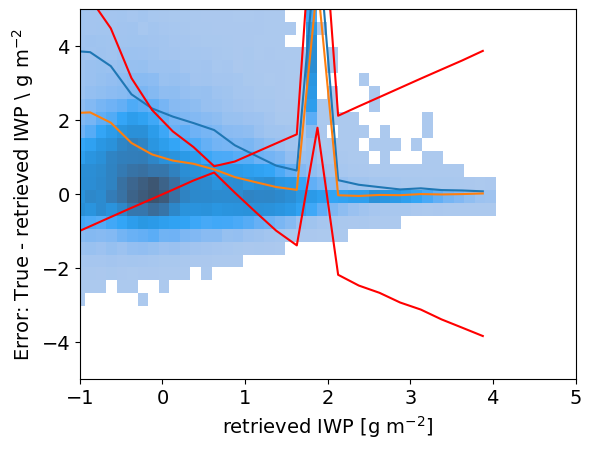

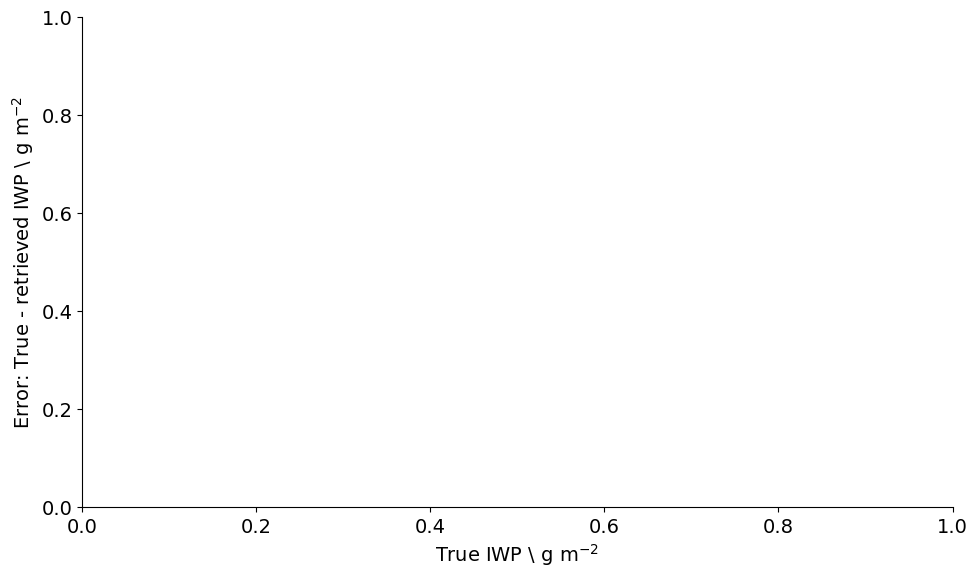

In [186]:
dev.plot_NN_error_v3(test_IWP,IWP_test_predictions_squared,variable)

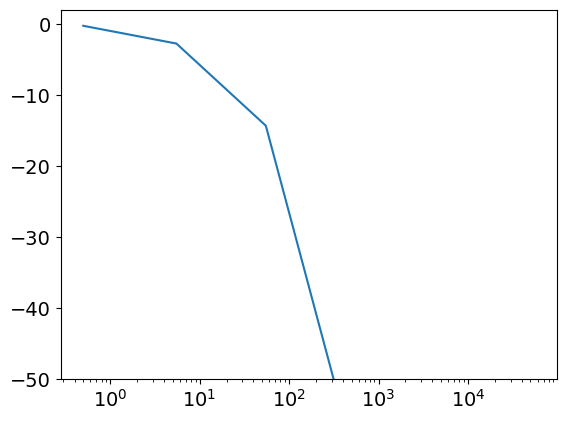

customaed bins
bin 1e-08 , bias:  -0.25335168838500977
bin 1.0 , bias:  -2.7521066665649414
bin 10.0 , bias:  -14.314390182495117
bin 100.0 , bias:  -61.36870193481445
bin 1000.0 , bias:  -69.01866912841797
bin 10000.0 , bias:  -3488.84326171875


In [197]:
bins,bin_centers,b_bias=dev.plot_and_calculate_NN_bias(test_IWP,IWP_test_predictions_squared,variable)
print('customaed bins')
for b,bias in zip(bins,b_bias):
    print('bin',b,', bias: ',bias)

0 0
0 0
0 0
0 0


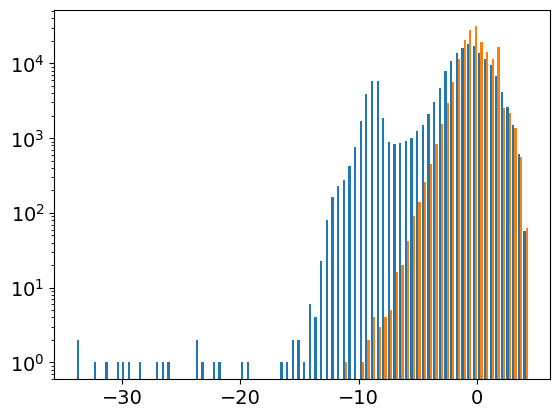

[9.338   nan 8.847 7.721 8.734 5.021 6.508 6.856 6.365 4.268 4.838 5.442
 5.239 4.386 3.937 3.551 3.492 3.398 3.822 3.72  3.617 3.515 3.581 3.541
 3.672 3.655 3.724 3.992 4.063 4.171 3.972 4.14  4.128 3.975 3.915 3.879
 3.838 3.461 2.697 2.314 2.095 1.92  1.731 1.319 1.042 0.768 0.636 7.117
 0.375 0.25  0.187 0.124 0.154 0.107 0.096 0.073] [-9.338    nan -8.847 -7.721 -8.734 -2.315 -6.486 -6.856 -6.059 -4.171
 -2.828 -4.588 -4.737 -2.988 -2.401 -0.36  -0.154 -0.915  0.182  0.211
 -0.68  -0.483  0.546  0.602  0.898  1.151  1.213  1.739  1.91   2.179
  1.947  2.164  2.159  2.151  2.118  2.186  2.209  1.93   1.381  1.07
  0.905  0.818  0.667  0.458  0.321  0.19   0.113  5.743 -0.034 -0.051
 -0.025 -0.031 -0.002 -0.012 -0.001  0.015] [0.475   nan 0.529 1.381 0.257 6.334 1.869 1.389 1.766 3.405 4.587 2.495
 2.143 3.612 3.959 5.76  5.688 4.708 5.556 5.34  4.206 4.13  4.922 4.724
 4.777 4.771 4.583 4.861 4.782 4.796 4.315 4.283 4.026 3.769 3.485 3.306
 3.081 2.552 1.755 1.201 0.79  0.452 0.08

/tmp/ipykernel_465555/1507217205.py:51: RuntimeWarning: Mean of empty slice.
  b_error[i-1]= np.sqrt(((targets -predictions)**2).mean())
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_465555/1507217205.py:54: RuntimeWarning: Mean of empty slice.
  b_bias[i-1]= (predictions - targets).mean()
/tmp/ipykernel_465555/1507217205.py:56: RuntimeWarning: Mean of empty slice.
  b_std[i - 1] = np.sqrt(((predictions - b_bias[i-1])**2).mean())#np.std(predictions - b_bias[i-1])
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


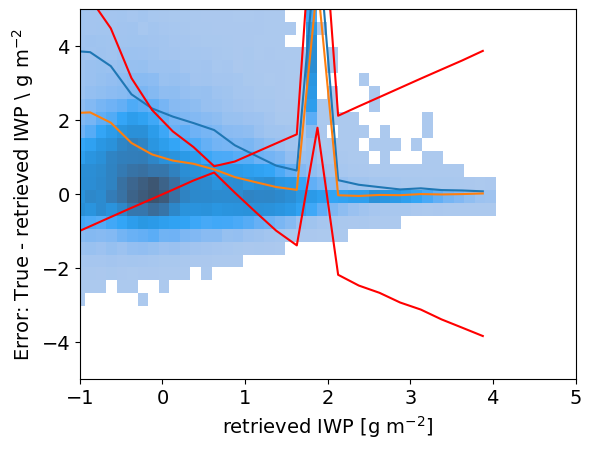

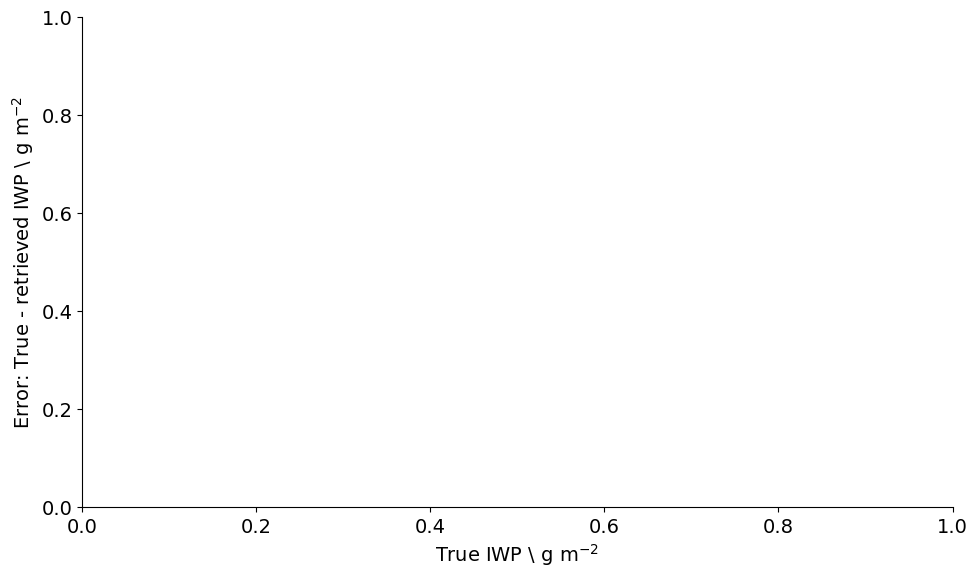

In [185]:
plot_NN_error_v3(test_IWP,IWP_test_predictions_squared,variable)

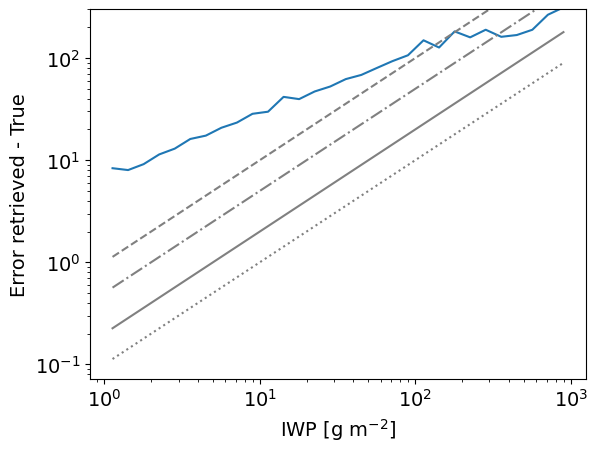

In [84]:
dev.plot_NN_error(IWP_test_predictions_squared,test_IWP,variable)

#### Saving NN-IWP model / retrieval to disk

In [14]:
dnn_model_iwp.save(f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_{altitude}m')
#dnn_model_iwp.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NN_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m')

# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
IWP_test_predictions_squared = IWP_test_predictions_cliped**2

# Saving collocated ICON data to netcdf file
filename = (f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/train_test_data_nn_24-32-1_reg_{altitude}m.nc')
ds = Dataset(filename,'w','NETCDF4')

# profile and frequency dimensions
ds.createDimension('train_cases',len(IWP_train))
ds.createDimension('test_cases',len(IWP_test))
ds.createDimension('freq',24)

# TBs
tb_train_var = ds.createVariable('tb_train','float64',('train_cases','freq'))
tb_train_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of training data set'
tb_train_var.setncattr('units','K')
tb_train_var[:,:] = TBs_train[:,:]
tb_test_var = ds.createVariable('tb_test','float64',('test_cases','freq'))
tb_test_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of test data set'
tb_test_var.setncattr('units','K')
tb_test_var[:,:] = TBs_test[:,:]

# IWP
iwp_train_var = ds.createVariable('iwp_train','float64',('train_cases'))
iwp_train_var.long_name = 'ICON simulated IWP values of training data set'
iwp_train_var.setncattr('units','g m2')
iwp_train_var[:] = IWP_train[:]
iwp_test_var = ds.createVariable('iwp_test','float64',('test_cases'))
iwp_test_var.long_name = 'ICON simulated IWP values of test data set'
iwp_test_var.setncattr('units','g m2')
iwp_test_var[:] = IWP_test[:]
iwp_retr_var = ds.createVariable('iwp_retrieved','float64',('test_cases'))
iwp_retr_var.long_name = 'Retrieved IWP values of test data set'
iwp_retr_var.setncattr('units','g m2')
iwp_retr_var[:] = IWP_test_predictions_squared[:]

# LWP
lwp_train_var = ds.createVariable('lwp','float64',('train_cases'))
lwp_train_var.long_name = 'ICON simulated LWP values of training data set'
lwp_train_var.setncattr('units','g m2')
lwp_train_var[:] = LWP_train[:]
lwp_test_var = ds.createVariable('lwp_test','float64',('test_cases'))
lwp_test_var.long_name = 'ICON simulated LWP values of test data set'
lwp_test_var.setncattr('units','g m2')
lwp_test_var[:] = LWP_test[:]

# IWV
iwv_train_var = ds.createVariable('iwv','float64',('train_cases'))
iwv_train_var.long_name = 'ICON simulated IWV values of training data set'
iwv_train_var.setncattr('units','g m2')
iwv_train_var[:] = IWV_train[:]
iwv_test_var = ds.createVariable('iwv_test','float64',('test_cases'))
iwv_test_var.long_name = 'ICON simulated IWV values of test data set'
iwv_test_var.setncattr('units','g m2')
iwv_test_var[:] = IWV_test[:]

ds.close()

INFO:tensorflow:Assets written to: /home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_12500m/assets


INFO:tensorflow:Assets written to: /home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_12500m/assets


489/489 [==============================] - 0s 495us/step
Negative predictions: 1.5 %


## IWV 

In [33]:
variable=  "IWV" #



#### Definition & compilation of network

In [43]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32 #20#
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50 #100#

In [44]:
 # define & compile nn-model for iwv with specified settings
dnn_model_iwv = dev.define_and_compile_nn(TBs_train_scaled, NR_of_NEURONS_L1, BIAS_INIT, WEIGHT_INIT, ACTIVATION_HL, ACTIVATION_OP, LOSS_FUNCTION, LEARNING_RATE)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Training of IWV neural network

CPU times: user 4min 51s, sys: 8.71 s, total: 5min
Wall time: 3min 58s


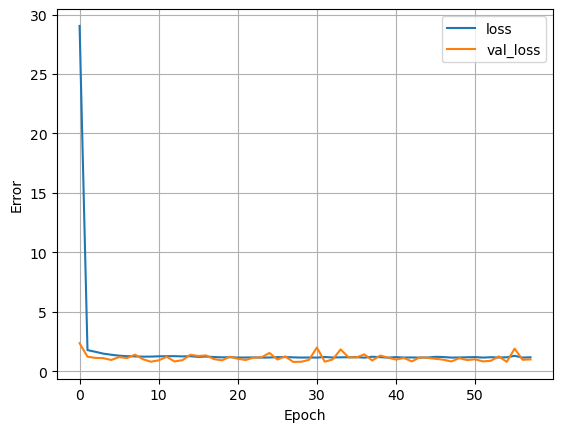

In [45]:
%%time
dnn_model_iwv = dev.train_NN(dnn_model_iwv, TBs_train_scaled, train_IWV, EPOCHS, BATCH_SIZE, plotting = True)

#plt.savefig('/home/u/u301238/master_thesis/plots/NN/NN_IWP_training_error_loss_24-32-1.jpg',bbox_inches='tight',dpi=200)

In [8]:
#Or load model
variable='IWV'
#altitude = 14450 #from prep-for-NN-training.py script
path=(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/')

dnn_model_iwv = tf.keras.models.load_model(path+f'dnn_model_{variable}_24-32-1_reg_{altitude}m_v2.keras',compile=False)
test_IWV=np.load(path+f'dnn_model_{variable}_24-32-1_reg_14450m_v2_test_{variable}.npy')
TBs_test_scaled=np.load(path+f'dnn_model_{variable}_24-32-1_reg_14450m_v2_test_TB_scaled.npy')

In [39]:
path

'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_IWV/dnn_model_IWV_24-32-1_reg_13850m_v1.keras'

### NN-IWV performance on PAMTRA test dataset

5381/5381 ━━━━━━━━━━━━━━━━━━━━ 2s 370us/step
Negative predictions: 0.0 %
Bias before cliping:  47.32
Bias after cliping:  47.32


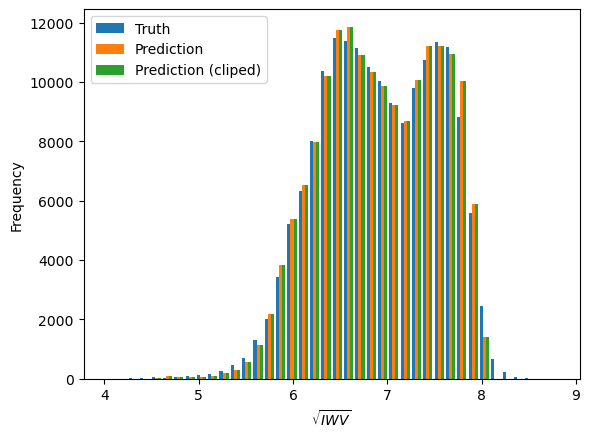

In [46]:
# predict sqrt(IWV) with neural network for given TBs
IWV_test_predictions = dnn_model_iwv.predict(TBs_test_scaled)[:,0]

# clip neural network output / predictions (set negative values to zero)
IWV_test_predictions_cliped = dev.clip_nn_output(IWV_test_predictions,truth=True)

# retransform neural network predictions from sqrt to linear IWV values
IWV_test_predictions_squared = IWV_test_predictions_cliped**2

#plot histograms of comparison of truth, prediction and clipped prediciton
dev.plot_truth_prediction_sqrt(test_IWV, (IWV_test_predictions), (IWV_test_predictions_cliped),variable='IWV')


In [52]:
IWV_test_predictions

array([7.528, 7.599, 7.518, ..., 6.441, 6.441, 6.429],
      shape=(125208,), dtype=float32)

bias:  0.05  corr:  1.0  rmse:  0.86


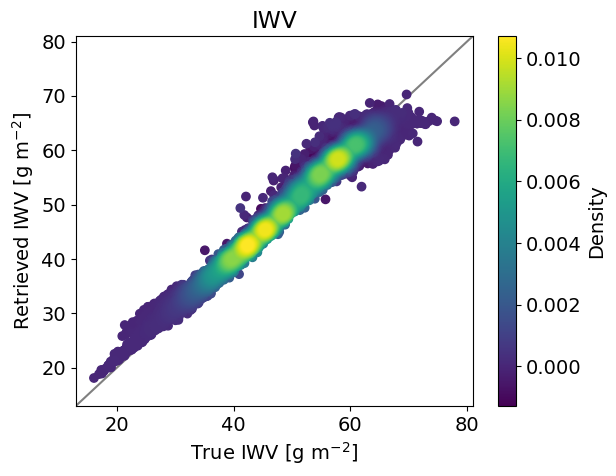

In [42]:
dev.scatter_hyd(test_IWV, IWV_test_predictions_squared, 'IWV')


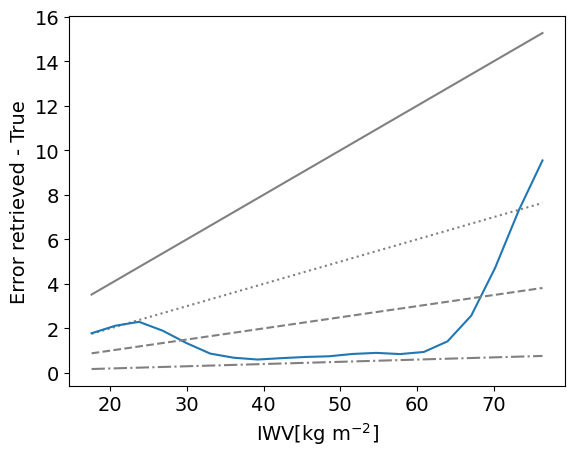

In [48]:
plot_NN_error(test_IWV,IWV_test_predictions_squared,variable)

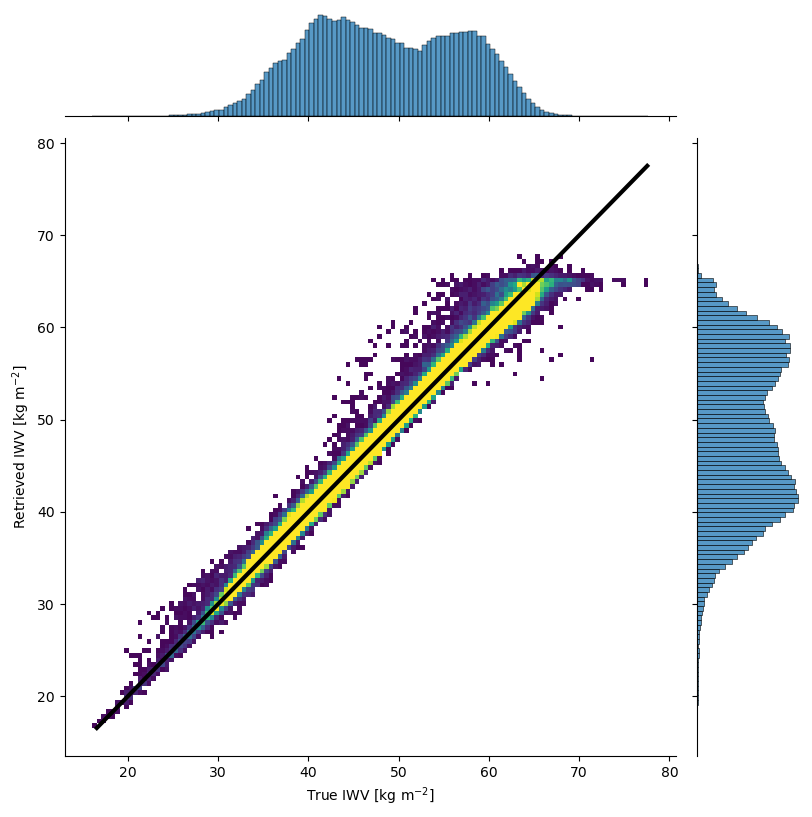

In [10]:
dev.plot_scatter_log_v2(test_IWV, IWV_test_predictions_squared, variable='IWV',kind='linear')

In [21]:


def plot_scatter_log( test_hyd,hyd_test_predictions_squared, variable,kind = 'log',plotname=None):
    
    
    #fig, axs = plt.subplots(figsize=(9,8))
    fig, axs = plt.subplot_mosaic([['histx', '.'],
                               ['scatter', 'histy']],
                              figsize=(6, 6),
                              width_ratios=(5, 1), height_ratios=(1, 5),
                              layout='constrained')

        
    if kind == 'log':
        
        test_hyd_log = test_hyd.copy()
        test_hyd_log[test_hyd_log==0] = 10**(-16)
        hyd_test_predictions_squared_log = hyd_test_predictions_squared.copy()
        hyd_test_predictions_squared_log[hyd_test_predictions_squared_log==0] = 10**(-16)
        
        a = np.log10(test_hyd_log)
        b = np.log10(hyd_test_predictions_squared_log)
        if variable != 'IWV':
            a[a<0.] = 0
            b[b<0.] = 0
        
        #a[a<0.] = np.nan
        #b[b<0.] = np.nan
        
        #a = test_hyd.copy()
        #b = hyd_test_predictions_squared.copy()
        
        #a[a<1.] = 1.
        #b[b<1.] = 1.
    if kind=='lin':
        a = (test_hyd)
        b = (hyd_test_predictions_squared)
        a[a<0.] = 0
        b[b<0.] = 0
    
    nans = np.logical_or(np.isnan(a), np.isnan(b))
    a = a[~nans]
    b = b[~nans]
    
    maxval = max(np.max(a),np.max(b))
    minval = max(np.min(a),np.min(b))
    if variable == 'IWV':
        minval-=5
        maxval+=5
        
    # Calculate the point density
    ab = np.vstack([a,b])
    c = scipy.stats.gaussian_kde(ab)(ab)
    
    # Sort the points by density, so that the densest points are plotted last
    idx = c.argsort()
    a, b, c = a[idx], b[idx], c[idx]
    
    bias = np.round((np.mean(b) - np.mean(a)),2)
    corr = np.round((scipy.stats.pearsonr(a,b)[0]),2)
    rmse = np.round(np.sqrt(np.nanmean((b-a)**2)),2)
    
    axs['scatter'].grid(alpha=0.5,which='both')
    if variable != 'IWV':
        hyd_true = np.arange(1,np.nanmax(test_hyd),0.01)
    else:
        hyd_true = np.arange(minval,maxval,0.01)
    RE_0 = hyd_true
    RE_80_plus = (0.8*hyd_true)+hyd_true
    RE_80_minus = (-0.8*hyd_true)+hyd_true
    RE_50_plus = (0.5*hyd_true)+hyd_true
    RE_5_plus = (0.05*hyd_true)+hyd_true
    RE_5_minus = (-0.05*hyd_true)+hyd_true
    RE_50_minus = (-0.5*hyd_true)+hyd_true
    RE_20_plus = (0.2*hyd_true)+hyd_true
    RE_20_minus = (-0.2*hyd_true)+hyd_true
    RE_20_minus[RE_20_minus<1.]=np.nan
    RE_50_minus[RE_50_minus<1.]=np.nan
    RE_80_minus[RE_80_minus<1.]=np.nan
      
    #axs.scatter(y_test, y_test_predictions**2)
    # no labels

        
    if kind == 'log':
        #sc = axs['scatter'].scatter(10**a,10**b,c=c,s=15,cmap='viridis',vmin=0,vmax=0.3)
        sc = axs['scatter'].scatter(10**a,10**b)#,c=c,s=15,cmap='viridis',vmin=0,vmax=0.3)
        #sc = axs.scatter(a,b,c=c,s=8,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
        
        
        #axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')

        
        axs['scatter'].set_xscale('log')
        axs['scatter'].set_yscale('log')
        axs['scatter'].set_xlabel(f'Target {variable} \\ g m$^{-2}$')
        axs['scatter'].set_ylabel(f'NN Predicted {variable} \\ g m$^{-2}$')
        if variable == 'IWV':
            axs['scatter'].plot(np.arange(10**minval,10**maxval),np.arange(10**minval,10**maxval),linewidth=3,color='black',alpha=1,label='1:1')
            axs['histx'].hist(10**a,bins=10 ** np.linspace(minval, maxval, 40),log=True, color='slategray')
            axs['histy'].hist(10**b,bins=10 ** np.linspace(minval, maxval, 40),log=True, color='slategray',orientation='horizontal')
        else:            
            axs['scatter'].plot(np.arange(10**0,10**maxval),np.arange(10**0,10**maxval),linewidth=3,color='black',alpha=1,label='1:1')
            axs['histx'].hist(10**a,bins=10 ** np.linspace(np.log10(1), maxval, 40),log=True, color='slategray')
            axs['histy'].hist(10**b,bins=10 ** np.linspace(np.log10(1), maxval, 40),log=True, color='slategray',orientation='horizontal')
        
        axs['histx'].set_xscale('log')
        axs['histy'].set_yscale('log')

        axs['histx'].tick_params(axis="x", labelbottom=False)
        axs['histy'].tick_params(axis="y", labelleft=False)  
        #axs.set_ylim(bottom=1)
        #axs.set_xlim(left=1)
    if kind=='lin':
        #no log axes!
        sc = axs['scatter'].scatter(a,b,c=c,s=15,cmap='viridis',vmin=0,vmax=0.025)
        #sc = axs.scatter(a,b,c=c,s=8,cmap='viridis',vmin=np.min(c),vmax=np.max(c))
        
        #axs.plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
        if variable == 'IWV':
            axs['scatter'].plot(np.arange(0,maxval+5),np.arange(0,maxval+5),linewidth=2,color='black',alpha=1,label='1:1')
            axs['scatter'].set_ylim(bottom=minval,top=maxval)
            axs['scatter'].set_xlim(left=minval,right=maxval)

            axs['histx'].hist(a,bins=np.linspace(minval, maxval, 40),log=True, color='slategray')
            axs['histy'].hist(b,bins=np.linspace(minval, maxval, 40),log=True, color='slategray',orientation='horizontal')
            axs['histy'].set_ylim(bottom=minval,top=maxval)
            axs['histx'].set_xlim(left=minval,right=maxval)
            axs['scatter'].set_xlabel(f'Target {variable} '+'\\ kg m$^{-2}$')
            axs['scatter'].set_ylabel(f'NN Predicted {variable} '+'\\ kg m$^{-2}$')

        else:
            axs['scatter'].plot(np.arange(0,maxval),np.arange(0,maxval),linewidth=3,color='black',alpha=1,label='1:1')
    
            axs['histx'].hist(a,bins=np.linspace(0, maxval, 40),log=True, color='slategray')
            axs['histy'].hist(b,bins=np.linspace(0, maxval, 40),log=True, color='slategray',orientation='horizontal')
            #axs['histx'].set_xscale('log')
        #axs['histy'].set_yscale('log')
    
        axs['histx'].tick_params(axis="x", labelbottom=False)
        axs['histy'].tick_params(axis="y", labelleft=False)  
    if variable != 'IWV':
        #plotlines
        axs['scatter'].plot(hyd_true,RE_20_plus,linewidth=1,linestyle='dotted',color='black',alpha=0.9,label='±20%')
        axs['scatter'].plot(hyd_true,RE_20_minus,linewidth=1,linestyle='dotted',color='black',alpha=0.9)
        axs['scatter'].plot(hyd_true,RE_50_plus,linewidth=1,linestyle='dashed',color='black',alpha=0.9,label='±50%')
        axs['scatter'].plot(hyd_true,RE_50_minus,linewidth=1,linestyle='dashed',color='black',alpha=0.9)
        axs['scatter'].plot(hyd_true,RE_80_plus,linewidth=1,linestyle='dashdot',color='black',alpha=0.9,label='±80%')
        axs['scatter'].plot(hyd_true,RE_80_minus,linewidth=1,linestyle='dashdot',color='black',alpha=0.9)
            
    else:
        axs['scatter'].plot(hyd_true,RE_5_plus,linewidth=2,linestyle='dashed',color='black',alpha=0.9,label='±5%')
        axs['scatter'].plot(hyd_true,RE_5_minus,linewidth=2,linestyle='dashed',color='black',alpha=0.9)
        axs['scatter'].plot(hyd_true,RE_20_plus,linewidth=2,linestyle='dotted',color='black',alpha=0.9,label='±20%')
        axs['scatter'].plot(hyd_true,RE_20_minus,linewidth=2,linestyle='dotted',color='black',alpha=0.9)

    

    
        
    
    cbar_ax = fig.add_axes([0.839, 0.839, 0.02, 0.145])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label('Point density',size=10)
    
    axs['scatter'].legend()
    
    #axs.text(0.02, 0.8, 'Bias: '+str(bias), 
    #         transform=axs.transAxes, fontsize=20,
    #         verticalalignment='top')
    #axs.text(0.05, 0.885, 'RMSE: '+str(rmse), 
    #         transform=axs.transAxes, fontsize=20,
    #         verticalalignment='top')
    #axs.text(0.05, 0.81, 'Corr: '+str(corr), 
    #         transform=axs.transAxes, fontsize=20,
    #         verticalalignment='top')
    
    print('Bias: '+str(bias))
    print('RMSE: '+str(rmse))
    print('Corr: '+str(corr))
    if plotname != None:
        plt.savefig(f'/home/u/u301032/orcestra/plots/target_vs_predicted_scatter_hist_{variable}_{plotname}.jpg', dpi=400)

Bias: -0.08
RMSE: 0.68
Corr: 1.0
CPU times: user 1.41 s, sys: 44 ms, total: 1.46 s
Wall time: 141 ms


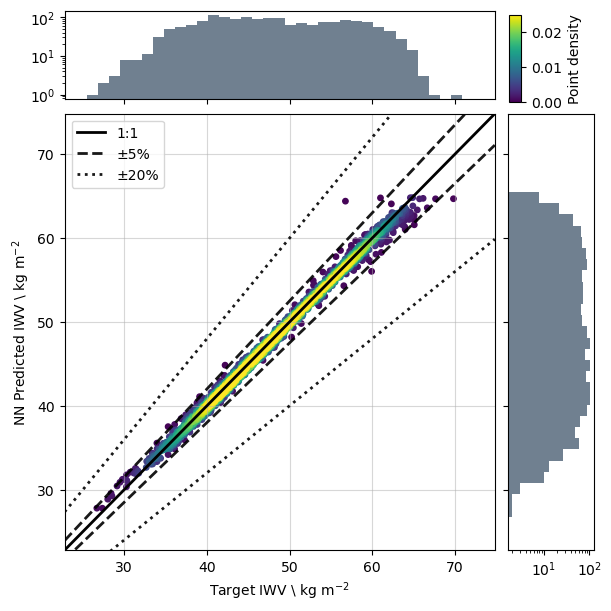

In [47]:
%%time
#plot_scatter_log(test_IWV, IWV_test_predictions_squared, variable ='IWV', kind = 'lin',plotname='v2')#'v2'
plot_scatter_log(test_IWV[::100], IWV_test_predictions_squared[::100], variable ='IWV', kind = 'lin',plotname=None)#'v2'

## Saving IWV NN

In [163]:
variable='IWV'
#altitude = 14450 #from prep-for-NN-training.py script
#dnn_model_iwp.save(f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/dnn_model_iwp_24-32-1_reg_{altitude}m')
dnn_model_iwv.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m.keras')
#save mu and sigma
np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy',mu_train)
np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy',sigma_train)

## Application Halo flights 
#### maybe bring to different notebook

In [15]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
ds_iwv_kw=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_iwv_kw.nc")
ds_sondes=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_sondes.nc")
ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 

target_date ='2024-08-11'# '2024-09-16'#'2024-09-19'#'2024-09-26'#'2024-08-11'
def sel_target_date(target_date,ds):
  target_datetime = pd.to_datetime(target_date)
  if 'time' in ds.coords:
     ds_filtered=ds.sel(time=slice(target_datetime, target_datetime + pd.Timedelta(days=1)))
  elif 'sonde_time' in ds.coords:
    ds_filtered = ds.where(ds['sonde_time'].dt.date == xr.DataArray(pd.to_datetime(target_date).date()), drop=True)
  else:
    print("please check dimension names for time dimension")
  return ds_filtered
#ds_HAMP=sel_target_date(target_date,ds_HAMP) 
#ds_sondes_f=sel_target_date(target_date,ds_sondes)
#ds_halo_altitude=sel_target_date(target_date,ds_halo_altitude)

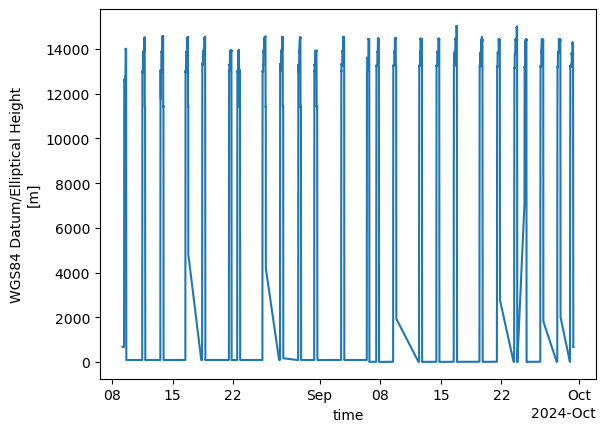

In [16]:
#ds_halo_altitude['alt'].plot()
ds_HAMP['plane_altitude'].plot()

In [17]:
variable='IWV'
print(ds_HAMP.frequency)
ds_hamp=ds_HAMP

excluded_frequencies = ds_hamp.frequency.where(ds_hamp.frequency!=184.81, drop=True)

# Step 2: Filter the dataset to exclude the specified frequency
ds_hamp = ds_hamp.sel(frequency=excluded_frequencies)
print(ds_hamp.TBs)
#ds_HAMP_scaled_array=[]
#for i in range(len(flight_levels)):
#NN_IWP_retrieval
#    ds_HAMP_scaled_array.append(standardize_nn_input_data_v2(np.asarray(ds_hamp.TBs.values),mu=mu_train,sigma=sigma_train))
#IWV_halo_predictions = dnn_model_iwv.predict(ds_HAMP_scaled)[:,0]**2    

def find_nearest_value(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def retrieve_IWV(TBs,altitudes):
    
    levels = np.array([find_nearest_value(flight_levels,altitudes[i]) for i in range(len(altitudes))])
    IWV = np.zeros(len(TBs))
    IWV[:] = np.nan
    for i in range(len(flight_levels)):
        altitude =flight_levels[i]
        if len(levels[levels==altitude]) != 0:
            print(f"Retrieving from {altitude} ({len(levels[levels==altitude])} TBs)")
            #hier modul load
            mu_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy')
            sigma_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + '_v1_'+ str(altitude) +'m.npy')
            
            ds_hamp_scaled=standardize_nn_input_data_v2(np.asarray(ds_hamp.TBs[levels==altitude].values),mu=mu_train,sigma=sigma_train)
            #print('trying to mini',np.asarray(ds_hamp.TBs[levels==altitude].values).shape)
            #print('shape hampscaled',ds_HAMP_scaled.shape)
            dnn_model_iwv = tf.keras.models.load_model(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m.keras',compile=False)
            IWV[np.where(levels==altitude)] = dnn_model_iwv.predict(ds_hamp_scaled)[:,0]**2
    # Indicate the fraction of negative predictions (possible as the sqrt of IWP is retrieved).
    print("")
    print((len(IWV[IWV<0])/len(IWV)),"% negative predictions (=clipped to 0).")
    print("")
    # If negative IWP values exist, they are clipped to 0.
    IWV[IWV<0] = 0.
    # clip everything below 10500km
    IWV[altitudes<=10500] =np.nan
    levels[altitudes<=10500] =0

    return IWV, levels 
IWV, levels =retrieve_IWV(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values)

<xarray.DataArray 'frequency' (frequency: 25)> Size: 100B
array([ 22.24,  23.04,  23.84,  25.44,  26.24,  27.84,  31.4 ,  50.3 ,  51.76,
        52.8 ,  53.75,  54.94,  56.66,  58.  ,  90.  , 120.15, 121.05, 122.95,
       127.25, 183.91, 184.81, 185.81, 186.81, 188.31, 190.81], dtype=float32)
Coordinates:
  * frequency  (frequency) float32 100B 22.24 23.04 23.84 ... 186.8 188.3 190.8
<xarray.DataArray 'TBs' (time: 3750412, frequency: 24)> Size: 360MB
[90009888 values with dtype=float32]
Coordinates:
  * frequency  (frequency) float32 96B 22.24 23.04 23.84 ... 186.8 188.3 190.8
  * time       (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... 2024-09-30T...
Attributes:
    long_name:  TB Map
    units:      K
Retrieving from 11400 (1136192 TBs)
35506/35506 ━━━━━━━━━━━━━━━━━━━━ 13s 369us/step
Retrieving from 12650 (83445 TBs)
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step
Retrieving from 13000 (200682 TBs)
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 2s 390us/step
Retrieving from 13250 (545792 TBs)
170

In [20]:
ds_hamp

<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 24)
Coordinates:
  * frequency             (frequency) float32 96B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables:
    AziAng                (time, frequency) float32 360MB ...
    ElAng                 (time, frequency) float32 360MB ...
    RF                    (time, frequency) float64 720MB ...
    TBs                   (time, frequency) float32 360MB nan nan ... nan nan
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    mask_amplifier_fault  (time, frequency) int64 720MB ...
    mask_sea_land         (time) int64 30MB ...
    plane_altitude        (time) float64 30MB 679.7 679.7 679.7 ... 681.0 681.0
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV                   (time) float64 30MB nan nan nan nan ... nan nan nan
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

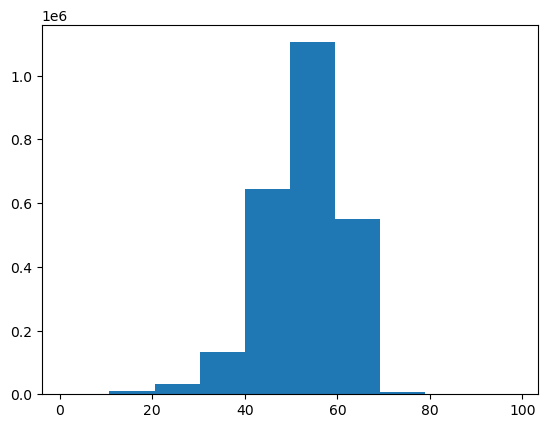

In [21]:
IWV.shape
ds_hamp['IWV']= (('time',), IWV)
plt.hist(ds_hamp.IWV)
#ds_hamp.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1_alllevels.nc ')

In [205]:
#altitudes=ds_hamp['plane_altitude']
#TBs=ds_hamp['TBs']
#levels = np.array([find_nearest_value(flight_levels,altitudes[i]) for i in range(len(altitudes))])
#IWV = np.zeros(len(TBs))
#IWV[:] = np.nan
print(levels[110000:])

[14450 14450 14450 ... 11400 11400 11400]


In [14]:
dnn_model_iwv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_1 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
print(ds_HAMP_scaled.shape,TBs_test_scaled.shape)

(3750412, 24) (125208, 24)


In [16]:
ds_HAMP_scaled.shape
IWV_halo_predictions = dnn_model_iwv.predict(ds_HAMP_scaled)[:,0]




IWV_halo_predictions_squared =IWV_halo_predictions**2

117201/117201 ━━━━━━━━━━━━━━━━━━━━ 45s 386us/step


In [41]:
# put predictions back into HAMP Dataset
print(len(IWV_halo_predictions_squared),ds_HAMP)
ds_HAMP['IWV_myret']= (('time',), IWV_halo_predictions_squared)
#ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1.nc ')

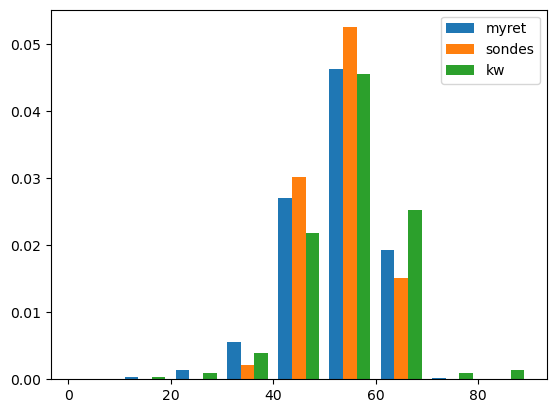

In [19]:
bins = np.arange(0,100,10)

#plt.hist(,bins=bins) # is this first retrival?? with nice data 
#IWV_halo_predictions_squared
plt.hist([ds_hamp.IWV,ds_sondes.iwv,ds_iwv_kw.IWV],bins=bins,label=['myret','sondes','kw'],density=True)#,fill=False)#,color='g')
#plt.hist(,bins=bins,fill=False)
#ds_sondes
plt.legend()

In [ ]:

# predict sqrt(IWP) with neural network for given TBs
IWP_test_predictions = dnn_model_iwp.predict(TBs_test_scaled)[:,0]
# clip neural network output / predictions (set negative values to zero)
IWP_test_predictions_cliped = src.clip_nn_output(IWP_test_predictions)
# retransform neural network predictions from sqrt to linear LWP values
IWP_test_predictions_squared = IWP_test_predictions_cliped**2

# Saving collocated ICON data to netcdf file
filename = (f'/home/u/u301238/master_thesis/nn/dnn_model_iwp_all_levels/train_test_data_nn_24-32-1_reg_{altitude}m.nc')
ds = Dataset(filename,'w','NETCDF4')

# profile and frequency dimensions
ds.createDimension('train_cases',len(IWP_train))
ds.createDimension('test_cases',len(IWP_test))
ds.createDimension('freq',24)

# TBs
tb_train_var = ds.createVariable('tb_train','float64',('train_cases','freq'))
tb_train_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of training data set'
tb_train_var.setncattr('units','K')
tb_train_var[:,:] = TBs_train[:,:]
tb_test_var = ds.createVariable('tb_test','float64',('test_cases','freq'))
tb_test_var.long_name = 'ICON-PAMTRA simulated brightness temperatures of test data set'
tb_test_var.setncattr('units','K')
tb_test_var[:,:] = TBs_test[:,:]

# IWP
iwp_train_var = ds.createVariable('iwp_train','float64',('train_cases'))
iwp_train_var.long_name = 'ICON simulated IWP values of training data set'
iwp_train_var.setncattr('units','g m2')
iwp_train_var[:] = IWP_train[:]
iwp_test_var = ds.createVariable('iwp_test','float64',('test_cases'))
iwp_test_var.long_name = 'ICON simulated IWP values of test data set'
iwp_test_var.setncattr('units','g m2')
iwp_test_var[:] = IWP_test[:]
iwp_retr_var = ds.createVariable('iwp_retrieved','float64',('test_cases'))
iwp_retr_var.long_name = 'Retrieved IWP values of test data set'
iwp_retr_var.setncattr('units','g m2')
iwp_retr_var[:] = IWP_test_predictions_squared[:]

# LWP
lwp_train_var = ds.createVariable('lwp','float64',('train_cases'))
lwp_train_var.long_name = 'ICON simulated LWP values of training data set'
lwp_train_var.setncattr('units','g m2')
lwp_train_var[:] = LWP_train[:]
lwp_test_var = ds.createVariable('lwp_test','float64',('test_cases'))
lwp_test_var.long_name = 'ICON simulated LWP values of test data set'
lwp_test_var.setncattr('units','g m2')
lwp_test_var[:] = LWP_test[:]

# IWV
iwv_train_var = ds.createVariable('iwv','float64',('train_cases'))
iwv_train_var.long_name = 'ICON simulated IWV values of training data set'
iwv_train_var.setncattr('units','g m2')
iwv_train_var[:] = IWV_train[:]
iwv_test_var = ds.createVariable('iwv_test','float64',('test_cases'))
iwv_test_var.long_name = 'ICON simulated IWV values of test data set'
iwv_test_var.setncattr('units','g m2')
iwv_test_var[:] = IWV_test[:]

ds.close()

## LWP 

Testing environment for neural network on only one altitude

In [17]:
#Or load model
variable='LWP'
#altitude = 14450 #from prep-for-NN-training.py script
path=(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_v1.keras')
dnn_model_lwp = tf.keras.models.load_model(path,compile=False)


In [12]:
### LOAD MODEL
variable='CLWP'

#dnn_model_clwp.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_LWP/dnn_model_{variable}_24-32-1_reg_{altitude}m_v1.keras')
#altitude = 14450 #from prep-for-NN-training.py script
path=(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_CLWP/')
dnn_model_clwp = tf.keras.models.load_model(path+f'dnn_model_{variable}_24-32-1_reg_{altitude}m_v2.keras',compile=False)
test_CLWP=np.load(path+f'dnn_model_{variable}_24-32-1_reg_14450m_v2_test_{variable}.npy')
TBs_test_scaled=np.load(path+f'dnn_model_{variable}_24-32-1_reg_14450m_v2_test_TB_scaled.npy')

In [40]:
variable=  "LWP" 
# names of variables to use:
##TBs_train_scaled, mu_train, sigma_train , TBs_train
## TBs_test_scaled 
## train_LWP
## test_LWP




#### Definition & compilation of network

In [96]:
# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50

In [97]:

# define & compile nn-model for lwp with specified settings
dnn_model_lwp = dev.define_and_compile_nn(TBs_train_scaled, NR_of_NEURONS_L1, BIAS_INIT, WEIGHT_INIT, ACTIVATION_HL, ACTIVATION_OP, LOSS_FUNCTION, LEARNING_RATE)
dnn_model_clwp = dev.define_and_compile_nn(TBs_train_scaled, NR_of_NEURONS_L1, BIAS_INIT, WEIGHT_INIT, ACTIVATION_HL, ACTIVATION_OP, LOSS_FUNCTION, LEARNING_RATE)


/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_13 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

...

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_14 (Dropout)            │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Training of LWP neural network

In [98]:
TBs_train_scaled
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

TBs_train_scaled2, train_CLWP2=unison_shuffled_copies(TBs_train_scaled, train_CLWP)


CPU times: user 16min 38s, sys: 57.4 s, total: 17min 36s
Wall time: 12min 34s


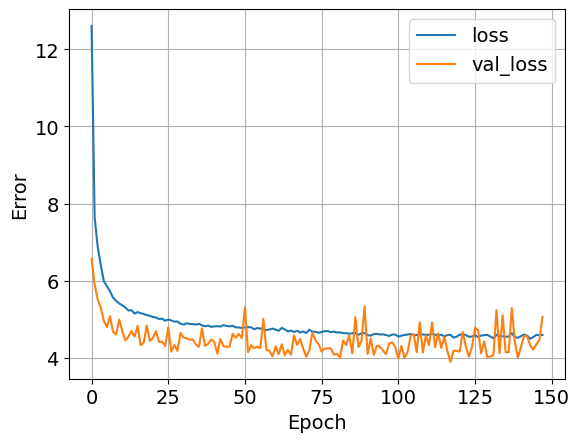

In [99]:
%%time


dnn_model_clwp = dev.train_NN(dnn_model_clwp, TBs_train_scaled2, train_CLWP2, EPOCHS, BATCH_SIZE, plotting = True)

In [20]:
%%time
dnn_model_lwp = dev.train_NN(dnn_model_lwp, TBs_train_scaled, train_LWP, EPOCHS, BATCH_SIZE, plotting = True)

ValueError: You must call `compile()` before using the model.

### NN-LWP performance on PAMTRA test dataset

5381/5381 ━━━━━━━━━━━━━━━━━━━━ 2s 374us/step
Negative predictions: 12.22 %
Bias before cliping:  2.74
Bias after cliping:  2.78


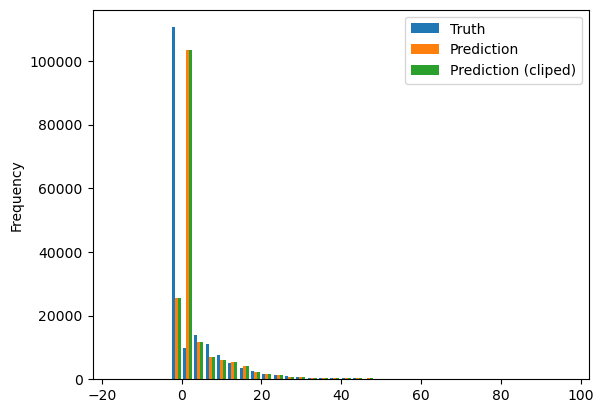

In [13]:
# predict sqrt(LWP) with neural network for given TBs
CLWP_test_predictions = dnn_model_clwp.predict(TBs_test_scaled)[:,0]

# clip neural network output / predictions (set negative values to zero)
CLWP_test_predictions_cliped = dev.clip_nn_output(CLWP_test_predictions,truth=True)

# retransform neural network predictions from sqrt to linear LWP values
CLWP_test_predictions_squared = CLWP_test_predictions_cliped**2

#plot histograms of comparison of truth, prediction and clipped prediciton
dev.plot_truth_prediction_sqrt(test_CLWP, CLWP_test_predictions, CLWP_test_predictions_cliped,variable='CLWP')

5381/5381 ━━━━━━━━━━━━━━━━━━━━ 2s 376us/step
Negative predictions: 16.03 %
Bias before cliping:  3.03
Bias after cliping:  3.08


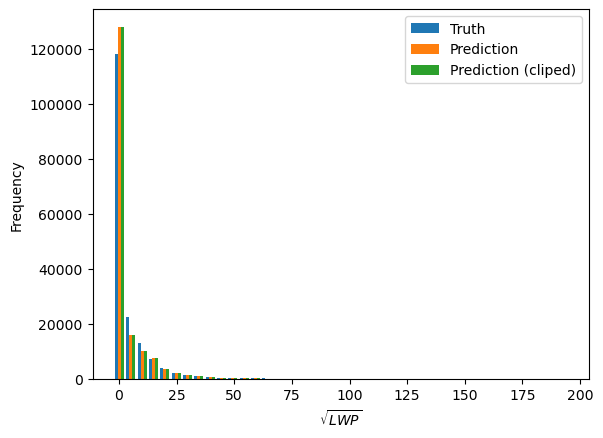

In [18]:
# predict sqrt(LWP) with neural network for given TBs
LWP_test_predictions = dnn_model_lwp.predict(TBs_test_scaled)[:,0]

# clip neural network output / predictions (set negative values to zero)
LWP_test_predictions_cliped = dev.clip_nn_output(LWP_test_predictions,truth=True)

# retransform neural network predictions from sqrt to linear LWP values
LWP_test_predictions_squared = LWP_test_predictions_cliped**2

#plot histograms of comparison of truth, prediction and clipped prediciton
dev.plot_truth_prediction_sqrt(test_LWP, LWP_test_predictions, LWP_test_predictions_cliped,variable='LWP')

Bias: -0.03
RMSE: 0.3
Corr: 0.95
CPU times: user 4min 13s, sys: 664 ms, total: 4min 13s
Wall time: 4min 13s


/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


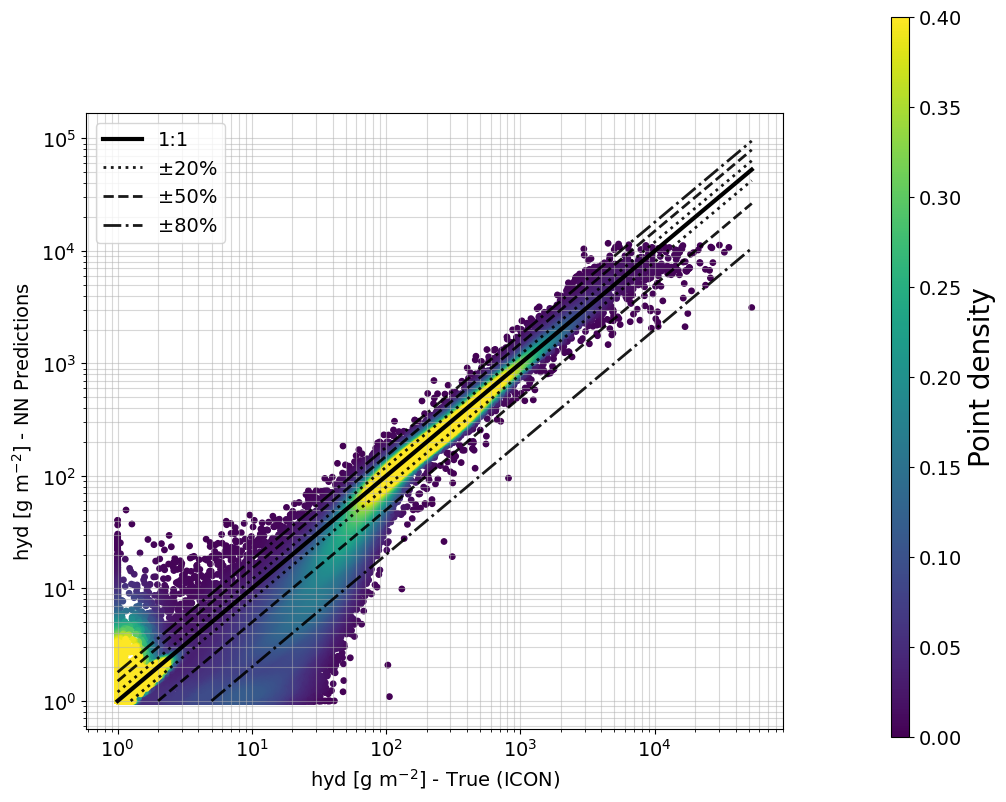

In [16]:
%%time
dev.plot_scatter_log(test_LWP, LWP_test_predictions_squared, variable ='LWP', kind = 'log')


Bias: -0.03
RMSE: 0.31
Corr: 0.94


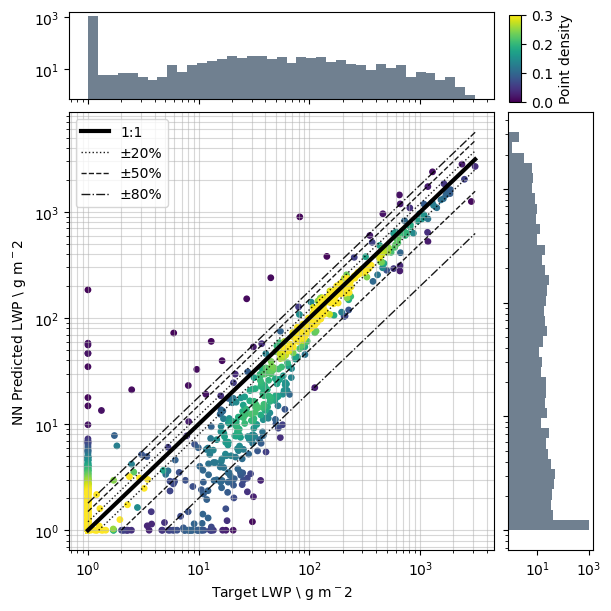

In [14]:
dev.plot_scatter_log(test_CLWP[::100], CLWP_test_predictions_squared[::100], variable ='LWP', kind = 'log')

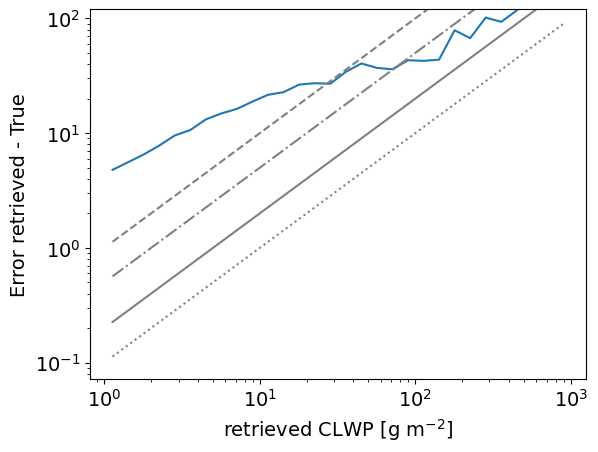

In [103]:
# Plot error

variable='CLWP'


dev.plot_NN_error(test_CLWP,CLWP_test_predictions_squared,variable)

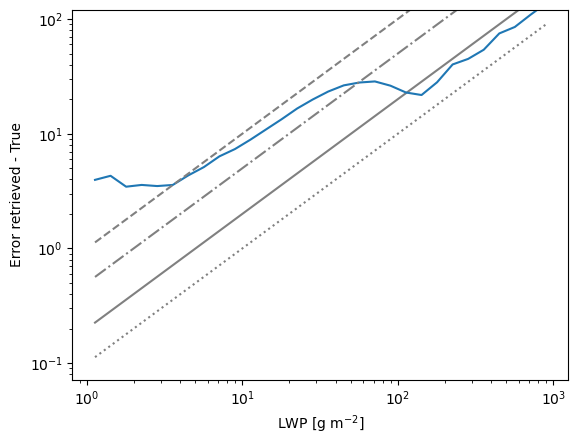

In [28]:
# Plot error

variable='LWP'


dev.plot_NN_error(test_LWP,LWP_test_predictions_squared,variable)

In [19]:

def plot_NN_error_v2(true, prediction,variable,filename=None):
    #so far used for graphics
    a,b=dev.no_nan_for_plot(true, prediction)
    # Define bin edges (e.g., 10 bins)
    num_bins = 20
    
    if variable == 'IWV':
        bins = np.linspace(np.min(a), np.max(a), num_bins + 1)
    else: 
        if variable == 'IWP':
            bin_max = 4 # max(a) #set to number of interest or maybe with 
        if variable == 'LWP':
            bin_max = 4
        bin_min = 0
        num_bins = (bin_max - bin_min) *4
        bins  = np.logspace(bin_min, bin_max, num_bins + 1)
    # 
    
    # Digitize 'a' to find out which bin each value belongs to
    bin_indices = np.digitize(b, bins)
    
    # Initialize arrays to hold results
    bin_centers = (bins[:-1] + bins[1:]) / 2
    b_error = np.empty(num_bins)
    rel_100 = np.empty(num_bins)
    # Calculate error (e.g., standard deviation) of 'b' within each bin
    for i in range(1, num_bins + 1):
        # Find indices of data points in the current bin
        in_bin = bin_indices == i
        #error as rmse between true and predicted # like in marek s paper
        targets= a[in_bin]
        predictions= b[in_bin]
        b_error[i-1]=np.sqrt(((targets -predictions)**2).mean())
        ## Calculate standard deviation of 'b' for these points
        #b_error[i - 1] = np.std(b[in_bin])
        #rel_100=
    # Plotting
    fig, axs = plt.subplots(figsize=(5,6))
    
    # Plot Error curves
    
    x=np.logspace(bin_min, bin_max, num_bins *10)
    if variable == 'IWV':
        error_curves =[1,5,10,25]
    else:
        error_curves =[10,25,50,100]
    
    for e in error_curves:
        
        plt.plot(x,(0.01*e)*x,linestyle=':',color='grey',label=e) #relative erorr 20 percent
        X=1200#1200#400 + (0.01*e)*800
        plt.text(X*(1/(0.01*e)), X,f'{e} %',verticalalignment='center_baseline',horizontalalignment='center',rotation=80)
        #plt.scatter(X*(1/(0.01*e)), X)

        
    #plt.plot(x,0.15*x,linestyle=':',color='grey',label='15') #relative erorr 10 percent
    
    plt.plot(bin_centers,b_error)
    
    #plt.errorbar(bin_centers, np.zeros_like(bin_centers), yerr=b_error, fmt='o', capsize=5)

    if variable == 'IWV':
        plt.xlabel('Retrieved '+ variable+'[kg m$^{-2}$]')
        plt.plot(bin_centers,0.05*bin_centers,linestyle='--',color='grey') #relative erorr 100 percent
        plt.plot(bin_centers,0.01*bin_centers,linestyle='-.',color='grey') #relative erorr 100 percent
    else:
        plt.xscale('log')
        #plt.yscale('log')
        plt.xlabel('Retrieved '+ variable+' \\ g m$^{-2}$')
        
        if  variable == 'IWP':
            plt.ylim(bottom=-50,top=1300)
        if  variable == 'LWP':
            plt.ylim(bottom=-50,top=1300)
        else:
            plt.ylim(top=120)       

    axs.spines['right'].set_visible(False)
    axs.spines['top'].set_visible(False)
    plt.ylabel('Error: True - retrieved '+variable+' \\ g m$^{-2}$')
    #plt.title('Error of b within each a bin')
    plt.tight_layout()
    if filename != None:
        plt.savefig(f'/home/u/u301032/orcestra/plots/{variable}_error_NN_{filename}.png',dpi=400)
    plt.show()

In [16]:

def plot_NN_error_v4(true, prediction,variable,filename=None):
    #so far used for graphics
    a,b=dev.no_nan_for_plot(true, prediction)
    # Define bin edges (e.g., 10 bins)
    num_bins = 20
    
    if variable == 'IWV':
        num_bins = 22
        bins = np.linspace(17.25, 72.25, num_bins+1 )#np.linspace(np.min(b), np.max(b), num_bins+1 )
    else: 
        if variable == 'IWP':
            bin_max = 4 # max(a) #set to number of interest or maybe with 
        if variable == 'LWP':
            bin_max = 4
        
        bin_min = 0
        num_bins = (bin_max - bin_min) *4
        bins  = np.logspace(bin_min, bin_max, num_bins + 1)
    # 
    
    # Digitize 'a' to find out which bin each value belongs to
    bin_indices = np.digitize(b, bins)
    
    # Initialize arrays to hold results
    bin_centers = (bins[:-1] + bins[1:]) / 2
    b_error = np.empty(num_bins)
    b_bias = np.empty(num_bins)
    b_std = np.empty(num_bins)
    
    rel_100 = np.empty(num_bins)
    # Calculate error (e.g., standard deviation) of 'b' within each bin
    for i in range(1, num_bins + 1):
        
        # Find indices of data points in the current bin
        in_bin = bin_indices == i
        #error as rmse between true and predicted # like in marek s paper
        targets= a[in_bin]
        predictions= b[in_bin]
        b_error[i-1]= np.sqrt(((predictions - targets)**2).mean())
        #rel_100[i-1]= np.sqrt((((predictions - targets)/predictions)**2).mean())
        b_bias[i-1]= (predictions - targets).mean()
        ## Calculate standard deviation of 'b' for these points
        #b_std[i - 1] = np.std(predictions - b_bias[i-1])
        #rel_100=

        print(np.sum(in_bin))
    
    # Plotting
    fig, axs = plt.subplots(figsize=(5,6))
    
    # Plot Error curves
    
    
    if variable == 'IWV':
        error_curves =[1,5,10]
        x=np.linspace(np.min(a), np.max(a),200)
    else:
        error_curves =[5,10,25,50,100]
        x=np.logspace(bin_min, bin_max, num_bins *10)
    for e in error_curves:
        plt.plot(x,-(0.01*e)*x,linestyle=':',color='grey',label=e)
        plt.plot(x,(0.01*e)*x,linestyle=':',color='grey',label=e) #relative erorr 20 percent
        if variable=='IWV':
            X=np.min(b)+1
            Y=X*((0.01*e))
            print(e,Y,X)
            #plt.scatter(X, Y)
            plt.text(X, Y,f'{e} %',verticalalignment='center_baseline',horizontalalignment='center',rotation=0)
        else:
            X=950#1200#400 + (0.01*e)*800
            plt.text(X*(1/(0.01*e)), X,f'{e} %',verticalalignment='center_baseline',horizontalalignment='center',rotation=80)
            #plt.scatter(X*(1/(0.01*e)), X)
    plt.plot(x,0*x,linestyle='-',color='grey',label=e)

        
    plt.plot(bin_centers,b_error)
    plt.plot(bin_centers,b_bias)
    #plt.errorbar(bin_centers, np.zeros_like(bin_centers), yerr=b_error, fmt='o', capsize=5)

    if variable == 'IWV':
        plt.xlabel('Retrieved '+ variable+' \\ kg m$^{-2}$')
        plt.ylabel('Error: Retrieved - true '+variable+' \\ kg m$^{-2}$')
        plt.ylim(bottom=-1,top=7)
        
        #plt.plot(bin_centers,0.05*bin_centers,linestyle='--',color='grey') #relative erorr 100 percent
        #plt.plot(bin_centers,0.01*bin_centers,linestyle='-.',color='grey') #relative erorr 100 percent
    else:
        plt.ylabel('Error: Retrieved - true '+variable+' \\ g m$^{-2}$')
        plt.xscale('log')
        #plt.yscale('log')
        plt.xlabel('Retrieved '+ variable+' \\ g m$^{-2}$')
        
        if  variable == 'IWP':
            plt.ylim(bottom=-220,top=1000) #(bottom=-320,top=1020) #
        elif  variable == 'LWP':
            plt.ylim(bottom=-420,top=1020) #(bottom=-220,top=1000) 
            #plt.yscale('log')
        else:
            plt.ylim(top=120)       

    axs.spines['right'].set_visible(False)
    axs.spines['top'].set_visible(False)
    
    #plt.title('Error of b within each a bin')
    plt.tight_layout()
    if filename != None:
        plt.savefig(f'/home/u/u301032/orcestra/plots/{variable}_error_biasRMSE_{filename}.png',dpi=400)
    plt.show()
    print(bin_centers,b_bias)


0
98
122
175
492
1541
4772
9585
12802
17772
18645
16172
14617
12924
14216
15716
15033
12844
4278
357
0
0
1 0.21314691 21.314692
5 1.0657346 21.314692
10 2.1314692 21.314692


/tmp/ipykernel_3952983/1371353643.py:39: RuntimeWarning: Mean of empty slice.
  b_error[i-1]= np.sqrt(((predictions - targets)**2).mean())
/tmp/ipykernel_3952983/1371353643.py:41: RuntimeWarning: Mean of empty slice.
  b_bias[i-1]= (predictions - targets).mean()


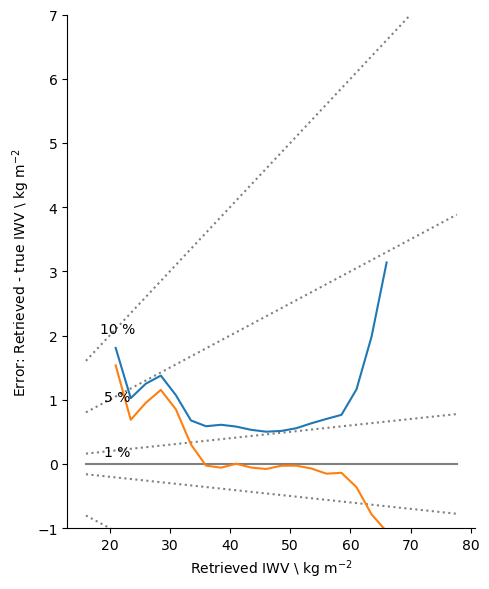

[18.5 21.  23.5 26.  28.5 31.  33.5 36.  38.5 41.  43.5 46.  48.5 51.
 53.5 56.  58.5 61.  63.5 66.  68.5 71. ] [   nan  1.535  0.688  0.952  1.153  0.85   0.303 -0.027 -0.058  0.003
 -0.057 -0.079 -0.029 -0.027 -0.071 -0.152 -0.139 -0.362 -0.786 -1.053
    nan    nan]


In [48]:
plot_NN_error_v4(test_IWV,IWV_test_predictions_squared,variable='IWV')

31
91
133
289
716
1793
4281
9153
13709
18228
17647
15349
14360
12772
13868
16343
16810
11429
4174
978
4
0
1 0.1753735 17.53735
5 0.8768675 17.53735
10 1.753735 17.53735


/tmp/ipykernel_3952983/1371353643.py:39: RuntimeWarning: Mean of empty slice.
  b_error[i-1]= np.sqrt(((predictions - targets)**2).mean())
/tmp/ipykernel_3952983/1371353643.py:41: RuntimeWarning: Mean of empty slice.
  b_bias[i-1]= (predictions - targets).mean()


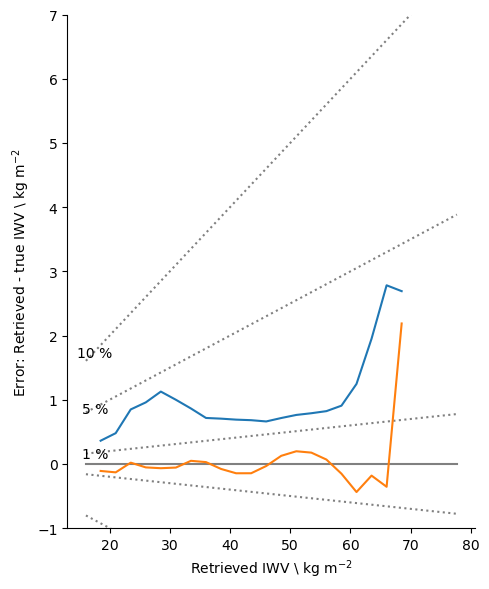

[18.5 21.  23.5 26.  28.5 31.  33.5 36.  38.5 41.  43.5 46.  48.5 51.
 53.5 56.  58.5 61.  63.5 66.  68.5 71. ] [-0.109 -0.132  0.02  -0.054 -0.067 -0.057  0.048  0.028 -0.078 -0.146
 -0.145 -0.033  0.126  0.197  0.176  0.068 -0.152 -0.438 -0.182 -0.356
  2.188    nan]


In [19]:
plot_NN_error_v4(test_IWV,IWV_test_predictions_squared,variable='IWV')#,filename='small_font'

14479
12084
8587
6039
4920
4678
4805
5428
6645
6428
3669
2444
1582
1129
1
0


/tmp/ipykernel_3952983/1371353643.py:39: RuntimeWarning: Mean of empty slice.
  b_error[i-1]= np.sqrt(((predictions - targets)**2).mean())
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3952983/1371353643.py:41: RuntimeWarning: Mean of empty slice.
  b_bias[i-1]= (predictions - targets).mean()


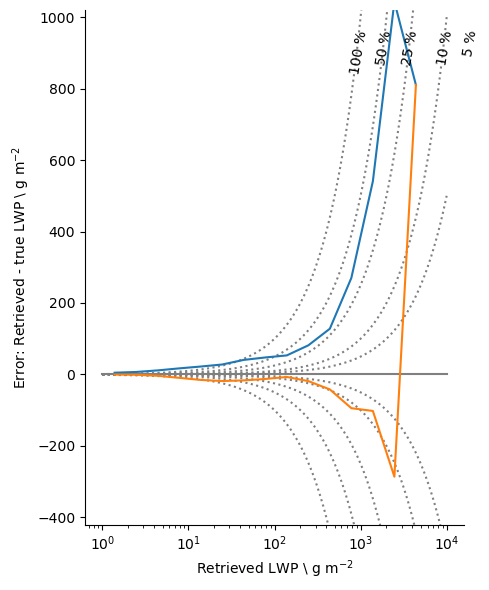

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [  -0.2     -0.861   -3.694   -9.472  -15.329  -18.397  -16.601  -12.599
   -7.008  -18.586  -41.89   -94.365 -102.153 -286.161  810.218      nan]


In [17]:
plot_NN_error_v4(test_CLWP,CLWP_test_predictions_squared,variable='LWP')#,filename='CLWP_v2'

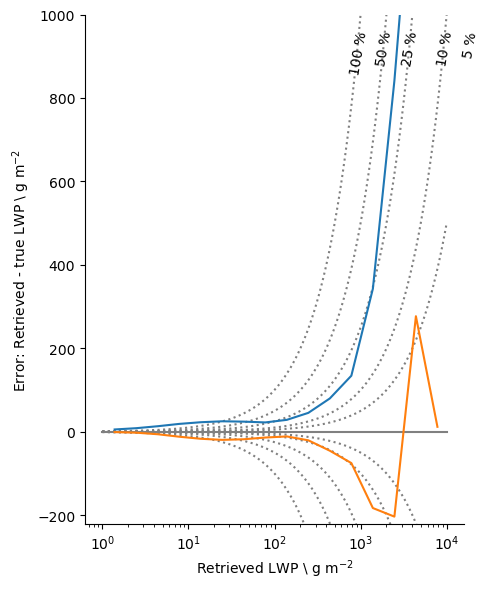

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [  -0.833   -2.272   -5.99   -11.936  -16.874  -19.5    -18.047  -13.906
  -11.297  -20.561  -45.527  -75.125 -182.913 -203.444  276.852   11.774]


In [70]:
plot_NN_error_v4(test_LWP,LWP_test_predictions_squared,variable='LWP')#,filename='TLWP_v1'

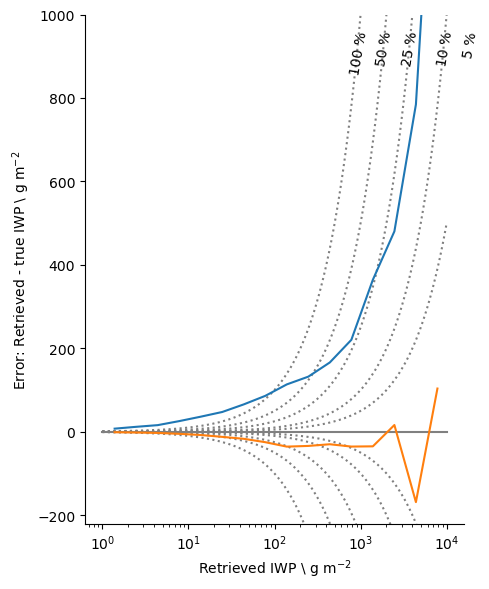

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [  -1.178   -1.883   -2.854   -5.04    -7.821  -12.322  -16.933  -25.07
  -35.685  -34.024  -30.017  -35.555  -34.999   16.072 -168.707  103.519]


In [71]:
plot_NN_error_v4(test_IWP,IWP_test_predictions_squared,variable='IWP')#,filename='v1'

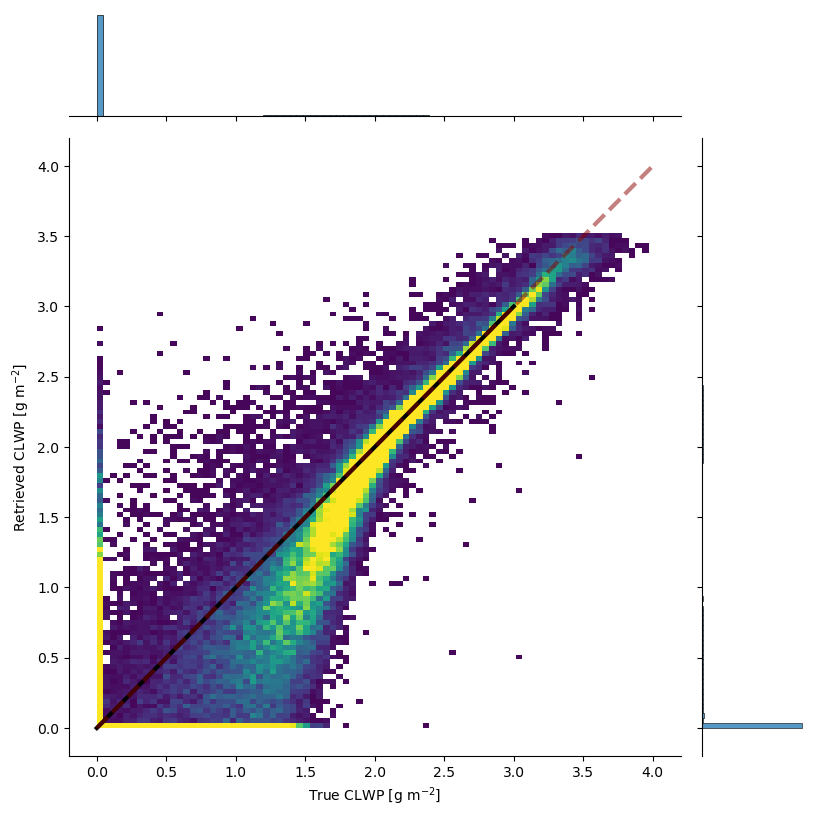

In [10]:
dev.plot_scatter_log_v2(test_CLWP, CLWP_test_predictions_squared, variable='CLWP')

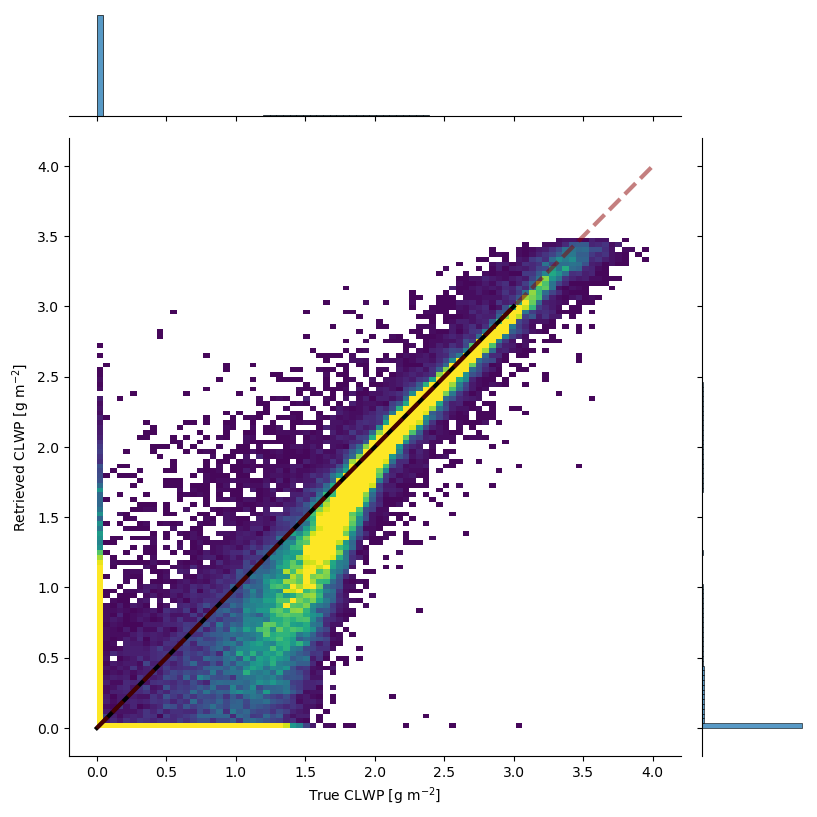

In [98]:
dev.plot_scatter_log_v2(test_CLWP, CLWP_test_predictions_squared, variable='CLWP')
# Unterschiede überlegen!

In [209]:
np.array([[0]+list(np.logspace(0,4,16))])

array([[    0.   ,     1.   ,     1.848,     3.415,     6.31 ,    11.659,
           21.544,    39.811,    73.564,   135.936,   251.189,   464.159,
          857.696,  1584.893,  2928.645,  5411.695, 10000.   ]])

In [226]:
def plot_NN_RMSE_error(true, prediction,variable,filename=None):
    #so far used for graphics
    a,b=dev.no_nan_for_plot(true, prediction)

    
    # Define bin edges (e.g., 10 bins)
    num_bins = 20
    
    if variable == 'IWV':
        bins = np.linspace(np.min(a), np.max(a), num_bins + 1)
    else: 
        if variable == 'IWP':
            bin_max = 4 # max(a) #set to number of interest or maybe with 
        if variable == 'LWP':
            bin_max = 4
        bin_min = 0
        num_bins = (bin_max - bin_min) *4
        bins  = np.logspace(bin_min, bin_max, num_bins + 1)
        #bins = np.array([[0]+list(np.logspace(0,4,16))])
    # 
    
    # Digitize 'a' to find out which bin each value belongs to
    bin_indices = np.digitize(b, bins)
    
    # Initialize arrays to hold results
    bin_centers = (bins[:-1] + bins[1:]) / 2
    b_error = np.empty(num_bins)
    b_bias = np.empty(num_bins)
    b_std = np.empty(num_bins)
    my_RMSE = np.empty(num_bins)
    RRMSE = np.empty(num_bins)
    MFE =  np.empty(num_bins)
    MRE =  np.empty(num_bins)
    # Calculate error (e.g., standard deviation) of 'b' within each bin
    for i in range(1, num_bins + 1):
        # Find indices of data points in the current bin
        in_bin = bin_indices == i
        #error as rmse between true and predicted # like in marek s paper
        targets= a[in_bin]
        predictions= b[in_bin]
        b_error[i-1]= np.sqrt(((predictions - targets)**2).mean())
        RRMSE[i-1]= np.sqrt(((((predictions - targets))**2).mean()/np.sum(predictions**2)))
        b_bias[i-1]= (predictions - targets).mean()
        ## Calculate standard deviation of 'b' for these points
        b_std[i - 1] = np.std(predictions - b_bias[i-1])
        MFE[i-1]=np.median(10**(np.abs(np.log10(predictions/targets))-1))
        #rel_100=
        MRE[i-1]=np.mean(np.abs(predictions - targets)/predictions)*100
    my_RMSE = b_error/bin_centers
    
    
    # Plotting
    fig, axs = plt.subplots(figsize=(5,6))
    
    # Plot Error curves
    
    x=np.logspace(bin_min, bin_max, num_bins *10)
    if variable == 'IWV':
        error_curves =[1,5,10,25]
    else:
        error_curves =[5,10,25,50,100]
    
    for e in error_curves:
        #plt.plot(x,-(0.01*e)*x,linestyle=':',color='grey',label=e)
        #plt.plot(x,(0.01*e)*x,linestyle=':',color='grey',label=e) #relative erorr 20 percent
        X=1200#1200#400 + (0.01*e)*800
        #plt.text(X*(1/(0.01*e)), X,f'{e} %',verticalalignment='center_baseline',horizontalalignment='center',rotation=80)
        #plt.scatter(X*(1/(0.01*e)), X)
    #plt.plot(x,0*x,linestyle='-',color='grey',label=e)
    plt.plot(bin_centers,100*my_RMSE,label='RMSE')  
    #plt.plot(bin_centers,100*RRMSE,label='RMSE')  
    plt.plot(bin_centers,MRE,label='MRE')
    #plt.plot(bin_centers,MFE,label='MFE')
    #plt.plot(bin_centers,b_error)
    #plt.plot(bin_centers,b_bias)
    #plt.errorbar(bin_centers, np.zeros_like(bin_centers), yerr=b_error, fmt='o', capsize=5)
    plt.legend()
    if variable == 'IWV':
        plt.xlabel('Retrieved '+ variable+'[kg m$^{-2}$]')
        plt.plot(bin_centers,0.05*bin_centers,linestyle='--',color='grey') #relative erorr 100 percent
        plt.plot(bin_centers,0.01*bin_centers,linestyle='-.',color='grey') #relative erorr 100 percent
    else:
        plt.xscale('log')
        #plt.yscale('log')
        plt.xlabel('Retrieved '+ variable+' \\ g m$^{-2}$')
        
        #if  variable == 'LWP':
            
    plt.ylim(bottom=0,top=300)
        #elif  variable == 'LWP':
            #plt.ylim(bottom=-150,top=1300)
            #plt.yscale('log')
        #else:
            #plt.ylim(top=120)       

    axs.spines['right'].set_visible(False)
    axs.spines['top'].set_visible(False)
    plt.ylabel('Root mean square error \\ percent')
    #plt.title('Error of b within each a bin')
    plt.tight_layout()
    if filename != None:
        plt.savefig(f'/home/u/u301032/orcestra/plots/{variable}_error_NN_{filename}.png',dpi=400)
    plt.show()
    print(bin_centers,b_bias)


In [25]:
def plot_NN_bias(true, prediction,variable,filename=None):
    #so far used for graphics
    a,b=dev.no_nan_for_plot(true, prediction)
    a[a<10**(-8)] = 10**(-8)
    b[b<10**(-8)] = 10**(-8)
    
    # Define bin edges (e.g., 10 bins)
    num_bins = 20
    
    if variable == 'IWV':
        bins = np.linspace(np.min(a), np.max(a), num_bins + 1)
    else: 
        if variable == 'IWP':
            bin_max = 4 # max(a) #set to number of interest or maybe with 
        if variable == 'LWP':
            bin_max = 4
        bin_min = 0
        num_bins = (bin_max - bin_min) *4
        bins  = np.logspace(bin_min, bin_max, num_bins + 1)
        #bins = np.array([[0]+list(np.logspace(0,4,16))])
    # 
    
    # Digitize 'a' to find out which bin each value belongs to
    bin_indices = np.digitize(b, bins)
    
    # Initialize arrays to hold results
    bin_centers = (bins[:-1] + bins[1:]) / 2
    b_error = np.empty(num_bins)
    b_bias = np.empty(num_bins)

    # Calculate error (e.g., standard deviation) of 'b' within each bin
    for i in range(1, num_bins + 1):
        # Find indices of data points in the current bin
        in_bin = bin_indices == i
        #error as rmse between true and predicted # like in marek s paper
        targets= a[in_bin]
        predictions= b[in_bin]

        
        b_bias[i-1]= (np.log10(predictions) - np.log10(targets)).mean()

    
    # Plotting
    fig, axs = plt.subplots(figsize=(5,6))
    
    # Plot Error curves
    
    x=np.logspace(bin_min, bin_max, num_bins *10)
    if variable == 'IWV':
        error_curves =[1,5,10,25]
    else:
        error_curves =[5,10,25,50,100]
    
    for e in error_curves:
        #plt.plot(x,-(0.01*e)*x,linestyle=':',color='grey',label=e)
        #plt.plot(x,(0.01*e)*x,linestyle=':',color='grey',label=e) #relative erorr 20 percent
        X=1200#1200#400 + (0.01*e)*800
        #plt.text(X*(1/(0.01*e)), X,f'{e} %',verticalalignment='center_baseline',horizontalalignment='center',rotation=80)
        #plt.scatter(X*(1/(0.01*e)), X)
    plt.plot(x,0*x,linestyle='-',color='grey',label=e)
    #plt.plot(bin_centers,100*my_RMSE,label='RMSE')  
    #plt.plot(bin_centers,100*RRMSE,label='RMSE')  
    #plt.plot(bin_centers,MRE,label='MRE')
    #plt.plot(bin_centers,MFE,label='MFE')
    #plt.plot(bin_centers,b_error)
    plt.plot(bin_centers,b_bias)
    #plt.errorbar(bin_centers, np.zeros_like(bin_centers), yerr=b_error, fmt='o', capsize=5)
    plt.legend()
    if variable == 'IWV':
        plt.xlabel('Retrieved '+ variable+'[kg m$^{-2}$]')
        plt.plot(bin_centers,0.05*bin_centers,linestyle='--',color='grey') #relative erorr 100 percent
        plt.plot(bin_centers,0.01*bin_centers,linestyle='-.',color='grey') #relative erorr 100 percent
    else:
        plt.xscale('log')
        #plt.yscale('log')
        plt.xlabel('Retrieved '+ variable+' \\ g m$^{-2}$')
        
        #if  variable == 'LWP':
            
    #plt.ylim(top=3)
        #elif  variable == 'LWP':
            #plt.ylim(bottom=-150,top=1300)
            #plt.yscale('log')
        #else:
            #plt.ylim(top=120)       

    axs.spines['right'].set_visible(False)
    axs.spines['top'].set_visible(False)
    plt.ylabel('Bias')
    #plt.title('Error of b within each a bin')
    plt.tight_layout()
    if filename != None:
        plt.savefig(f'/home/u/u301032/orcestra/plots/{variable}_error_NN_{filename}.png',dpi=400)
    plt.show()
    print(bin_centers,b_bias)


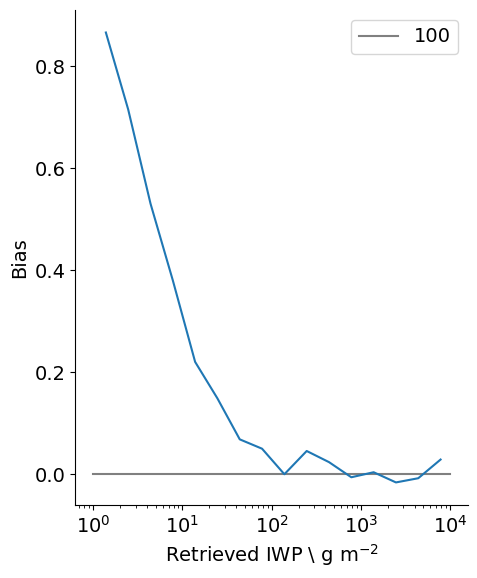

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [ 0.867  0.716  0.531  0.381  0.221  0.149  0.069  0.05   0.     0.046
  0.024 -0.006  0.004 -0.016 -0.008  0.029]


In [241]:
plot_NN_bias(test_IWP,IWP_test_predictions_creative,variable='IWP')

/tmp/ipykernel_2845172/241218404.py:40: RuntimeWarning: Mean of empty slice.
  b_bias[i-1]= (np.log10(predictions) - np.log10(targets)).mean()


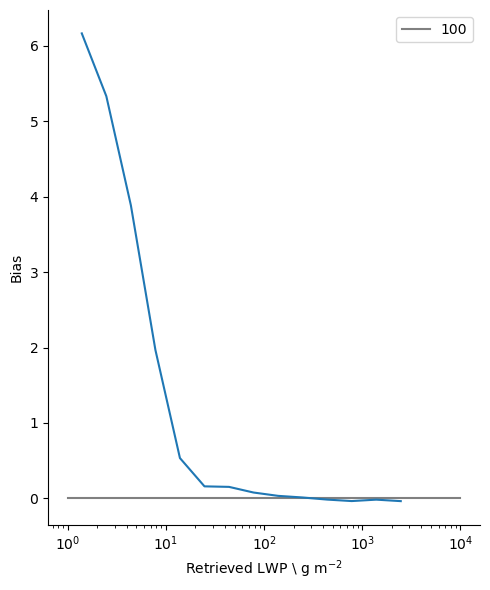

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [ 6.167  5.334  3.887  1.968  0.533  0.158  0.151  0.076  0.032  0.01
 -0.017 -0.037 -0.018 -0.038    nan    nan]


In [112]:
plot_NN_bias(test_CLWP,CLWP_test_predictions_squared,variable='LWP')

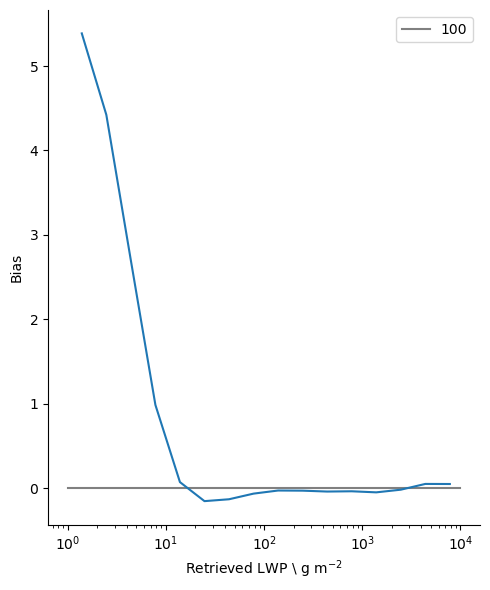

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [ 5.387  4.423  2.697  0.986  0.071 -0.154 -0.132 -0.065 -0.028 -0.03
 -0.04  -0.037 -0.05  -0.019  0.05   0.049]


In [26]:
plot_NN_bias(test_LWP,LWP_test_predictions_squared,variable='LWP')

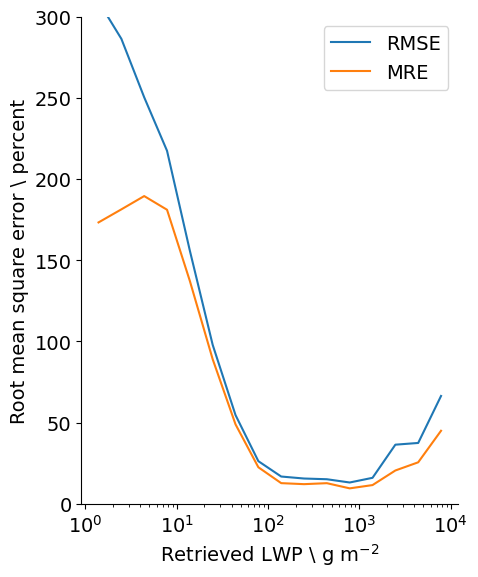

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [   -0.064    -0.872    -3.605    -9.707   -16.022   -19.088   -18.199
   -11.589    -1.292    -2.57    -18.239    17.896    66.36     22.301
   149.702 -1616.941]


In [227]:
plot_NN_RMSE_error(test_LWP,LWP_test_predictions_squared,variable='LWP')

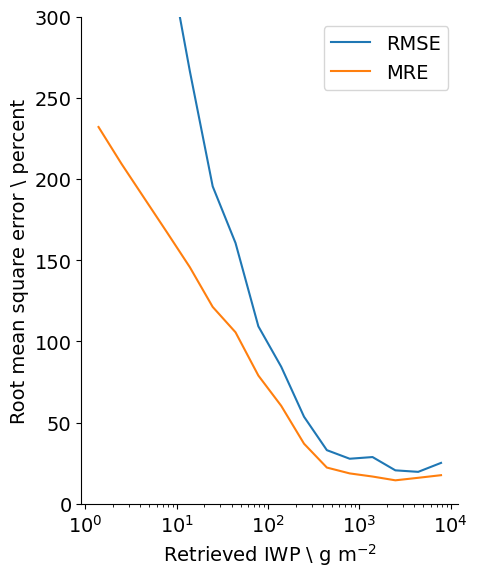

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [  -1.716   -2.648   -4.18    -6.44   -10.125  -13.712  -21.987  -26.065
  -37.549  -20.542  -12.394  -49.284  -58.79  -137.315 -150.963  206.016]


In [228]:
plot_NN_RMSE_error(test_IWP,IWP_test_predictions_creative,variable='IWP')

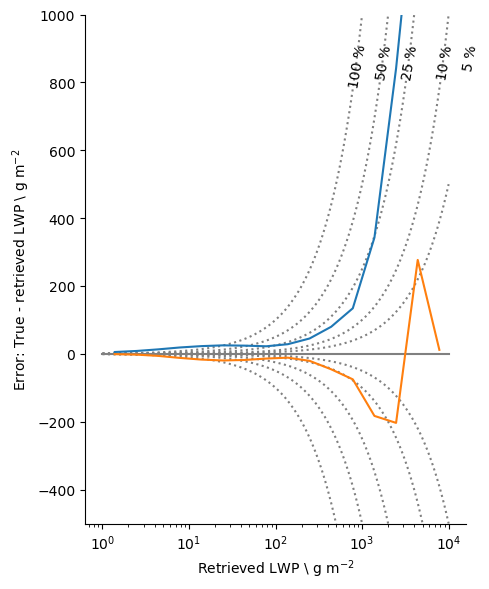

[   1.389    2.47     4.393    7.812   13.891   24.703   43.928   78.117
  138.914  247.028  439.285  781.171 1389.14  2470.279 4392.845 7811.707] [  -0.833   -2.272   -5.99   -11.936  -16.874  -19.5    -18.047  -13.906
  -11.297  -20.561  -45.527  -75.125 -182.913 -203.444  276.852   11.774]


In [21]:
plot_NN_error_v4(test_LWP,LWP_test_predictions_squared,variable='LWP')#,filename='log')

In [18]:
#SAVE
#np.save('/work/um0203/u301032/master_thesis/retrieval_test_data/IWV_test_predictions_squared_v2.npy',IWV_test_predictions_squared)
#np.save('/work/um0203/u301032/master_thesis/retrieval_test_data/IWP_test_predictions_squared_v2.npy',IWP_test_predictions_squared)
#np.save('/work/um0203/u301032/master_thesis/retrieval_test_data/CLWP_test_predictions_squared_v2.npy',CLWP_test_predictions_squared)

#np.save('/work/um0203/u301032/master_thesis/retrieval_test_data/test_CLWP_v2.npy',test_CLWP)
#np.save('/work/um0203/u301032/master_thesis/retrieval_test_data/test_IWP_v2.npy',test_IWP)
#np.save('/work/um0203/u301032/master_thesis/retrieval_test_data/test_IWV_v2.npy',test_IWV)


In [86]:
## LOAD teat and predicted data
IWV_test_predictions_squared=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/IWV_test_predictions_squared.npy')
IWP_test_predictions_squared=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/IWP_test_predictions_squared.npy')
LWP_test_predictions_squared=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/LWP_test_predictions_squared.npy')
CLWP_test_predictions_squared=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/CLWP_test_predictions_squared.npy')
test_LWP=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/test_LWP.npy')
test_CLWP=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/test_CLWP.npy')
test_IWP=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/test_IWP.npy')
test_IWV=np.load('/work/um0203/u301032/master_thesis/retrieval_test_data/test_IWV.npy')

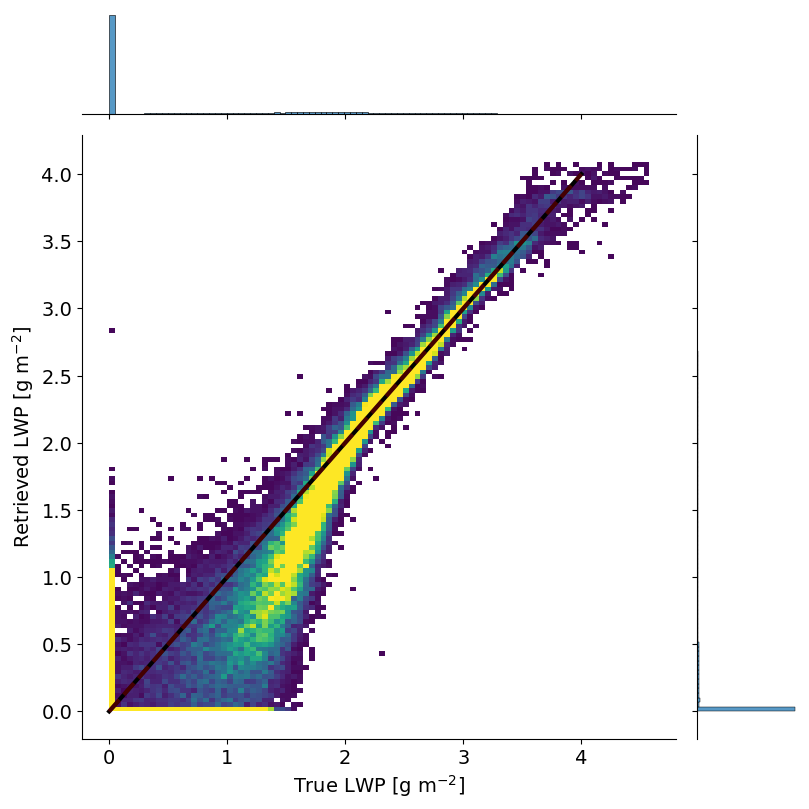

In [128]:
dev.plot_scatter_log_v2(test_LWP, LWP_test_predictions_squared, variable='LWP')
# Unterschiede überlegen!

## Analysiing existing NNs
#### Load true and predicted hydrometeors so that error calculation is possilbe

In [ ]:


variable= 'IWV'
training_version='v1'
altitude = 14450
train_hyd=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_train_{variable}.npy')
test_hyd=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_test_{variable}.npy')
#TODO load model and predict 
a = test_hyd
b = IWV_test_predictions_squared
nans = np.logical_or(np.isnan(a), np.isnan(b))
a = a[~nans]
b = b[~nans]   

# Training all heights

New, slicker approach

In [ ]:
variable = 'LWP' # 'IWP' # 'IWV' #'CLWP'# 

training_version = "v2"
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
flight_levels =[11400,12650,13000,13250,13600,13850,14450,15000	] #11400,12650,13000,13250,13600,13850,

# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50


#%% LOAD PREPROCESSED TRANING DATA
data=[]
names=[ 'IWV', 'IWP', 'LWP','cllvi','t_steps','cell_selection']
for i in range(len(names)):
    data.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_' + names[i] + '.npy'))
IWV, IWP, LWP,CLWP,t_steps,cell_selection =data
IWP=1000*IWP
LWP=1000*LWP
CLWP = 1000*CLWP

IWP[IWP<=10**(-9)]=10**(-9)
LWP[LWP<=10**(-9)]=10**(-9)
CLWP[CLWP<=10**(-9)]=10**(-9)
TBs_array=[]
mu_array=[]
sigma_array=[]

train_IWV,test_IWV=dev.splitting_train_test_2(IWV,t_steps)
train_LWP,test_LWP=dev.splitting_train_test_2(LWP,t_steps)
train_CLWP,test_CLWP=dev.splitting_train_test_2(CLWP,t_steps)
train_IWP,test_IWP=dev.splitting_train_test_2(IWP,t_steps)

def array_for_variable(v):
    match v:
        case 'IWP':
            return train_IWP, test_IWP
        case 'IWV':
            return train_IWV, test_IWV
        case 'LWP':
            return train_LWP, test_LWP
        case 'CLWP':
            return train_CLWP, test_CLWP
train_hyd, test_hyd = array_for_variable(variable)  

for altitude in flight_levels:
    print("altitude used for training:", altitude)
    # loading TBs of flight level:
    TBs=np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy')
    TB_input_vector = dev.array_setup(TBs,t_steps,cell_selection)
    train_TB, test_TB=dev.splitting_train_test_2(TB_input_vector,t_steps)
    TBs_train_scaled, mu_train, sigma_train = dev.standardize_nn_training_data(train_TB) 
    TBs_test_scaled = dev.standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 
    parameters_NN =[EPOCHS, BATCH_SIZE, NR_of_NEURONS_L1, BIAS_INIT, WEIGHT_INIT, ACTIVATION_HL, ACTIVATION_OP, LOSS_FUNCTION, LEARNING_RATE]
       
    dev.NN_train_save(TBs_train_scaled,TBs_test_scaled,train_hyd,test_hyd,variable,altitude,training_version, parameters_NN )
    #save mu and sigma
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy',mu_train)
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy',sigma_train)

















































altitude used for training: 11400













/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/regularization/dropout.py:42: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-10-08 20:12:12.820820: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout (Dropout)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

Previous approach

In [3]:
"""
Training of Neural Network

This script trains the Neural Network for all hights and all hydrometeors.

 Here one can enter the findings from from NN-development.ipnyb
 """


#%%noise
import tensorflow as tf
#import levenberg_marquardt as lm
import scipy.stats
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import seaborn as sns
from glob import glob
import xarray as xr
#import typhon as ty
import sys
#sys.path.append('/home/u/u301238/master_thesis/')
sys.path.append('/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/')
print(sys.path)
#import src

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)


#%% PARAMETERS

variable =  'CLWP'# 'LWP' # 'IWV' #'IWP' #
training_version = "v1.2"
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
flight_levels =[11400,12650,13000,13250,13600,13850,14450,15000	]






# General settings of the neural network
NR_of_NEURONS_L1 = 32
BIAS_INIT = 'zeros'
WEIGHT_INIT = 'random_normal'
ACTIVATION_HL = 'tanh'
ACTIVATION_OP = 'linear'
LOSS_FUNCTION = tf.keras.losses.MeanSquaredError()
LEARNING_RATE = 0.001

EPOCHS = 1000
BATCH_SIZE = 50



#%% LOAD PREPROCESSED TRANING DATA
data=[]
names=[ 'IWV', 'IWP', 'LWP','t_steps','cell_selection']
for i in range(len(names)):
    data.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_' + names[i] + '.npy'))
IWV, IWP, LWP,t_steps,cell_selection =data
IWP=1000*IWP
LWP=1000*LWP
IWP[IWP<1]=0.
LWP[LWP<1]=0.
TBs_array=[]
mu_array=[]
sigma_array=[]

#for altitude in flight_levels:
#    TBs_array.append(np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy'))






#%% Functions
### Standardizing Input
##### standardize all TBs along their respective channel as a normal distribution with mean 0 and std of 1
def standardize_nn_training_data(TBs_train):
        
    TBs_centered = np.zeros(TBs_train.shape)
    mu_train = np.zeros(TBs_train.shape[1])
    sigma_train = np.zeros(TBs_train.shape[1])
    for channel in range(TBs_train.shape[1]):

        mu_train[channel] = np.nanmean(TBs_train[:,channel])
        sigma_train[channel] = np.nanstd(TBs_train[:,channel])   

        TBs_centered[:,channel] = (TBs_train[:,channel] - mu_train[channel])/sigma_train[channel]
        
    return TBs_centered, mu_train, sigma_train
    
def standardize_nn_input_data_v2(TBs, mu, sigma):
    
    TBs = np.asarray(TBs)
    # if single TB observation provided extend dims to 2
    if len(TBs.shape) == 1:
        TBs = TBs[np.newaxis,:]
    
    TBs_centered = np.zeros(TBs.shape)
    for channel in range(TBs.shape[1]):

        TBs_centered[:,channel] = (TBs[:,channel] - mu[channel])/sigma[channel]
    
    return TBs_centered


def splitting_in_train_test_validate(A,t_steps,slices_train,slices_validate,slices_test):    
    # Splits in timesteps
    x=np.arange(0,A.shape[0]+1,A.shape[0]/len(t_steps))
    x=x.astype(int)
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_train])
    train=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_validate])
    validate=  A[indexes]
    
    indexes = np.concatenate([np.arange(x[i],x[j]) for i,j in slices_test])
    test=  A[indexes]
    
    return train,test,validate

a=np.arange(1,33,4)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_validate=np.asarray(l)    
a=np.arange(3,33,4)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_test=np.asarray(l)   
a=np.arange(0,33,2)
l=[]
for i in range(len(a)):
    l.append([a[i],a[i]+1])
slices_train=np.asarray(l)    


#%%
def array_for_variable(v):
    match v:
        case 'IWP':
            return IWP
        case 'IWV':
            return IWV
        case 'LWP':
            return LWP  
hyd = array_for_variable(variable)       

for altitude in flight_levels:

    train_hyd, test_hyd, validate_hyd = splitting_in_train_test_validate(hyd,t_steps,slices_train,slices_validate,slices_test)
    train_hyd=np.concatenate([train_hyd, validate_hyd])

    TBs=np.load('/work/um0203/u301032/master_thesis/ML_input/' + name_pamtra_run + '_TBs_altitude_' + str(altitude) + 'm.npy')
    ## Filter for unrealistic BTs missing and determine calculation of flight level
    TB_input_vector=TBs
    # Only necessary if one wants to exclude certain frequencies.
    TB_input_vector = np.concatenate((
            TB_input_vector[:,0:7], # K-Band
            TB_input_vector[:,7:14], # V-Band
            TB_input_vector[:,14:15], # W-Band
            TB_input_vector[:,15:19], # F-Band
            TB_input_vector[:,19:]), # G-Band
            axis=1)
    TB_input_vector.shape

    if (len(t_steps)*len(cell_selection)!=(TB_input_vector.shape[0])):
        print("Shape of TB does not match cell and time steps. Please check.")

        """
        # exclude profiles with unrealistic pamtra simulations
        TBs[TBs[:,20]<230] = np.nan   # TODO what are in our case unrealistic values?
        TB_input_vector = TBs[~np.isnan(TBs).any(axis=1),:] #TODO: count NANs. If NAN do not just drop , as index would get messed up
        IWP = IWP[~np.isnan(TBs).any(axis=1)]
        LWP = LWP[~np.isnan(TBs).any(axis=1)]
        IWV = IWV[~np.isnan(TBs).any(axis=1)]
        """
        if np.count_nonzero(np.isnan(TBs)) > 0:
            print("NaN values in Brightnesstemperature array. This may influence the rest of the Retrievaldeveloment, as they are not being filtered.")
    train_TB, test_TB, validate_TB = splitting_in_train_test_validate(TB_input_vector,t_steps,slices_train,slices_validate,slices_test)
    train_TB=np.concatenate([train_TB, validate_TB])

    TBs_train_scaled, mu_train, sigma_train = standardize_nn_training_data(train_TB) 
    TBs_test_scaled = standardize_nn_input_data_v2(test_TB,mu=mu_train,sigma=sigma_train) 
    TBs_validate_scaled = standardize_nn_input_data_v2(validate_TB,mu=mu_train,sigma=sigma_train)

    print("altitude used for training:", altitude)
    print('shape',TBs_train_scaled.shape, np.sqrt(train_hyd).shape)
    # compile network
    dnn_model_hyd = tf.keras.Sequential([
        tf.keras.layers.Dropout(rate=0.05, input_shape=(train_TB.shape[1],)),
        tf.keras.layers.Dense(NR_of_NEURONS_L1,
                              input_shape=(train_TB.shape[1],),
                              bias_initializer=BIAS_INIT,
                              kernel_initializer=WEIGHT_INIT,
                              kernel_regularizer="l2",
                              activation=ACTIVATION_HL,
                             ),
        tf.keras.layers.Dense(1,
                              activation=ACTIVATION_OP)])
    
    dnn_model_hyd.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                          loss=LOSS_FUNCTION,
                         )
    
    dnn_model_hyd.summary()

    
    
    #train network
    history = dnn_model_hyd.fit(
        TBs_train_scaled, np.sqrt(train_hyd),
        validation_split=0.2,
        #validation_data=(TBs_validate_scaled,validate_hyd),#new
        verbose=0,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)]
    )
    
    # use typhon ploting style
    #plt.style.use(ty.plots.styles.get('typhon'))
    
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    #plt.ylim(0,40)
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.grid(True)
    plt.legend()
    plt.title(variable)

    # Visualization of predictions
    hyd_test_predictions = dnn_model_hyd.predict(TBs_test_scaled)[:,0]
    hyd_test_predictions_squared =hyd_test_predictions**2
    fig, ax = plt.subplots()

    labels = [
        f"Truth",
        "Prediction",
        "Prediction (cliped)"]
    ax.hist(np.array([np.sqrt(test_hyd),hyd_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
    ax.set_xlabel(f"$\sqrt\{{variable}}$")
    ax.set_ylabel("Frequency")
    plt.legend()
    plt.show()

    dnn_model_hyd.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}.keras')
    #save mu and sigma
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy',mu_train)
    np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy',sigma_train)
    print("NN for",altitude,"m has been saved.")
    if altitude == 14450:
        train_hyd=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_train_{variable}.npy',train_TB)
        test_hyd=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_test_{variable}.npy',test_TB)
        train_TB=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_train_TB.npy',train_hyd)  #Hyd to train
        test_TB=np.save(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}_test_TB.npy',test_hyd)
        print("Training and Test data for",altitude,"m has been saved.")


<string>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\s'
<string>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\{'
<>:252: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3153939/232940195.py:252: SyntaxWarning: invalid escape sequence '\{'
  ax.set_xlabel(f"$\sqrt\{{variable}}$")
/tmp/ipykernel_3153939/232940195.py:252: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel(f"$\sqrt\{{variable}}$")


['/home/u/u301032/lib/python', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python312.zip', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/lib-dynload', '', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages', '/sw/spack-levante/miniforge3-24.11.3-2-Linux-x86_64-hbhytx/lib/python3.12/site-packages/setuptools/_vendor', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/', '/home/u/u301032/orcestra/NN_IWP_retrieval/NN_training_and_development/']


/tmp/ipykernel_3153939/232940195.py:252: SyntaxWarning: invalid escape sequence '\{'
  ax.set_xlabel(f"$\sqrt\{{variable}}$")
/tmp/ipykernel_3153939/232940195.py:252: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel(f"$\sqrt\{{variable}}$")


AttributeError: 'NoneType' object has no attribute 'shape'

In [6]:
hyd_test_predictions = dnn_model_hyd.predict(TBs_test_scaled)[:,0]
hyd_test_predictions_squared =hyd_test_predictions**2
fig, ax = plt.subplots()

labels = [
    f"Truth",
    "Prediction",
    "Prediction (cliped)"]
ax.hist(np.array([np.sqrt(test_hyd),hyd_test_predictions]).T,bins=25,label=labels)#,IWP_test_predictions_cliped
ax.set_xlabel("$\sqrt\{hyd}$")
ax.set_ylabel("Frequency")
plt.legend()
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_159319/3444522564.py:10: SyntaxWarning: invalid escape sequence '\s'
  ax.set_xlabel("$\sqrt\{hyd}$")


3913/3913 ━━━━━━━━━━━━━━━━━━━━ 2s 393us/step


ValueError: 
\sqrt\{hyd}
     ^
ParseSyntaxException: Expected \sqrt{value}, found '\'  (at char 5), (line:1, col:6)

<Figure size 640x480 with 1 Axes>

# Retreival Application




In [4]:

def halo_BT_read_in():
    #From function from src_comparison_halo_pamtra
  ds_halo=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
  ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 
  #ds_halo no sea please
  da_masked = ds_halo.TBs.where(ds_halo.mask_sea_land, drop=True)

  # use amplifier fault mask and land sea mask
  da_masked = da_masked.where(ds_halo.mask_amplifier_fault, drop=True)

    # filter 90 GHz channel for unrealitstic temperatures
  mask_90=(ds_halo.sel(frequency=90.).TBs<320).drop_vars('frequency') # 38  caases over 320
  da_masked = da_masked.where(mask_90, drop=True)
  #cut altitude:
  da_masked = da_masked.where(ds_halo.plane_altitude>=10500,drop=True)

  # add filtered data array to variable
  ds_halo['TBs']=  da_masked
  excluded_frequencies = ds_halo.frequency.where(ds_halo.frequency!=184.81, drop=True)
  # Step 2: Filter the dataset to exclude the specified frequency
  ds_halo = ds_halo.sel(frequency=excluded_frequencies)
  return ds_halo,ds_halo_altitude
ds_halo,ds_halo_altitude =    halo_BT_read_in() 

In [6]:
#ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
#ds_iwv_kw=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_iwv_kw.nc")
#ds_sondes=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_sondes.nc")
#ds_halo_altitude=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_altitude.nc") 

def standardize_nn_training_data(TBs_train):
        
    TBs_centered = np.zeros(TBs_train.shape)
    mu_train = np.zeros(TBs_train.shape[1])
    sigma_train = np.zeros(TBs_train.shape[1])
    for channel in range(TBs_train.shape[1]):

        mu_train[channel] = np.nanmean(TBs_train[:,channel])
        sigma_train[channel] = np.nanstd(TBs_train[:,channel])   

        TBs_centered[:,channel] = (TBs_train[:,channel] - mu_train[channel])/sigma_train[channel]
        
    return TBs_centered, mu_train, sigma_train
    
def standardize_nn_input_data_v2(TBs, mu, sigma):
    
    TBs = np.asarray(TBs)
    # if single TB observation provided extend dims to 2
    if len(TBs.shape) == 1:
        TBs = TBs[np.newaxis,:]
    
    TBs_centered = np.zeros(TBs.shape)
    for channel in range(TBs.shape[1]):

        TBs_centered[:,channel] = (TBs[:,channel] - mu[channel])/sigma[channel]
    
    return TBs_centered


#TODO use chp.pamtra_halo_BT_read_in(pamtra_file_names) for filtered BTs
name_pamtra_run = "cells_025x025_2h"#"all_area_1000th_cell" # 
flight_levels =[11400,12650,13000,13250,13600,13850,14450,15000	]
#variable='IWV' # 'LWP' # 'IWP' # 'CLWP'
training_version="v2"
#print(ds_HAMP.frequency)


#excluded_frequencies = ds_hamp.frequency.where(ds_hamp.frequency!=184.81, drop=True)

# Step 2: Filter the dataset to exclude the specified frequency
#ds_hamp = ds_hamp.sel(frequency=excluded_frequencies)
#print(ds_hamp.TBs)


def find_nearest_value(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def retrieve_hyd(TBs,altitudes,variable,training_version):
    
    levels = np.array([find_nearest_value(flight_levels,altitudes[i]) for i in range(len(altitudes))])
    hyd= np.zeros(len(TBs))
    hyd[:] = np.nan
    for i in range(len(flight_levels)):
        altitude =flight_levels[i]
        if len(levels[levels==altitude]) != 0:
            print(f"Retrieving from {altitude} ({len(levels[levels==altitude])} TBs)")
            #hier modul load
            mu_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/mu_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy')
            sigma_train=np.load(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/standardizing_parameters/sigma_' + name_pamtra_run + training_version + '_'+ str(altitude) +'m.npy')
            
            ds_hamp_scaled=standardize_nn_input_data_v2(np.asarray(ds_hamp.TBs[levels==altitude].values),mu=mu_train,sigma=sigma_train)

            dnn_model_hyd = tf.keras.models.load_model(f'/home/u/u301032/orcestra/NN_IWP_retrieval/NNs/NNs_{variable}/dnn_model_{variable}_24-32-1_reg_{altitude}m_{training_version}.keras',compile=False) #TODO adjust input name of retrieval
            hyd[np.where(levels==altitude)] = dnn_model_hyd.predict(ds_hamp_scaled)[:,0]**2
    # Indicate the fraction of negative predictions (possible as the sqrt of hyd is retrieved).
    print("")
    print((len(hyd[hyd<0])/len(hyd)),"% negative predictions (=clipped to 0).")
    print("")
    # If negative  values exist, they are clipped to 0.
    hyd[hyd<0] = 0.
    # clip everything below 10500km
    hyd[altitudes<=10500] =np.nan
    levels[altitudes<=10500] =0

    return hyd, levels 

ds_hamp=ds_halo
IWV, levels =retrieve_hyd(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values,'IWV',training_version)
IWP, levels =retrieve_hyd(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values,'IWP',training_version)
CLWP, levels =retrieve_hyd(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values,'CLWP',training_version)
TLWP, levels =retrieve_hyd(ds_hamp['TBs'].values,ds_hamp['plane_altitude'].values,'LWP',training_version)

Retrieving from 11400 (1136192 TBs)


2025-10-16 14:36:06.776332: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


35506/35506 ━━━━━━━━━━━━━━━━━━━━ 13s 370us/step
Retrieving from 12650 (83445 TBs)
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 385us/step
Retrieving from 13000 (200682 TBs)
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 2s 376us/step
Retrieving from 13250 (545792 TBs)
17056/17056 ━━━━━━━━━━━━━━━━━━━━ 6s 373us/step
Retrieving from 13600 (69133 TBs)
2161/2161 ━━━━━━━━━━━━━━━━━━━━ 1s 387us/step
Retrieving from 13850 (786923 TBs)
24592/24592 ━━━━━━━━━━━━━━━━━━━━ 9s 373us/step
Retrieving from 14450 (891355 TBs)
27855/27855 ━━━━━━━━━━━━━━━━━━━━ 10s 374us/step
Retrieving from 15000 (36890 TBs)
1153/1153 ━━━━━━━━━━━━━━━━━━━━ 0s 397us/step

0.0 % negative predictions (=clipped to 0).

Retrieving from 11400 (1136192 TBs)
35506/35506 ━━━━━━━━━━━━━━━━━━━━ 13s 377us/step
Retrieving from 12650 (83445 TBs)
2608/2608 ━━━━━━━━━━━━━━━━━━━━ 1s 385us/step
Retrieving from 13000 (200682 TBs)
6272/6272 ━━━━━━━━━━━━━━━━━━━━ 2s 378us/step
Retrieving from 13250 (545792 TBs)
17056/17056 ━━━━━━━━━━━━━━━━━━━━ 6s 372us/step
Retrieving from 1

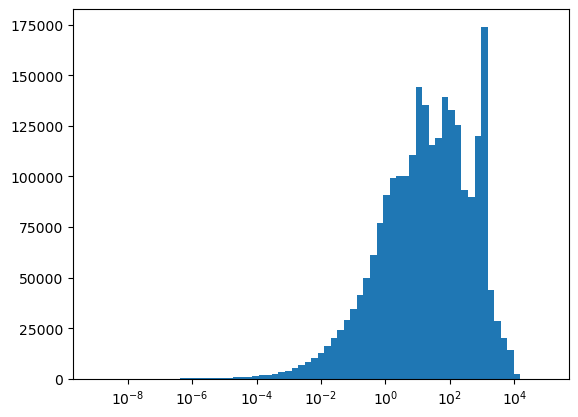

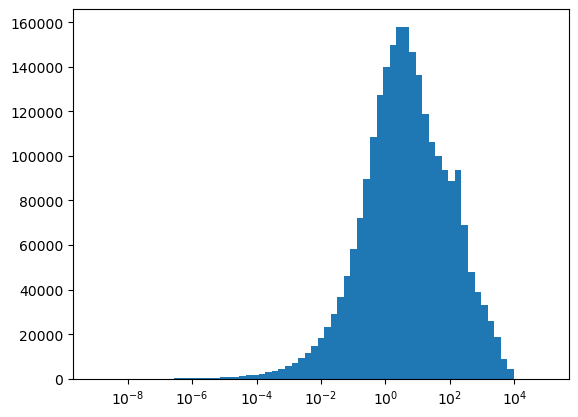

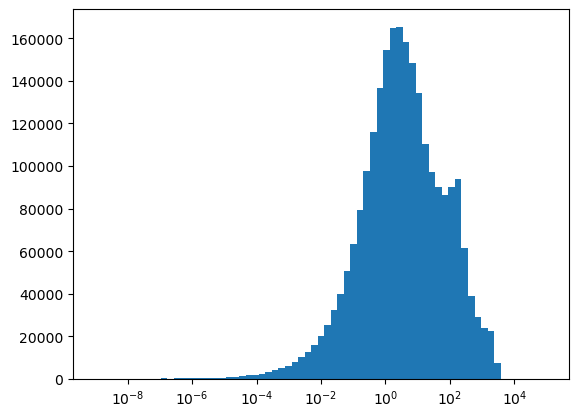

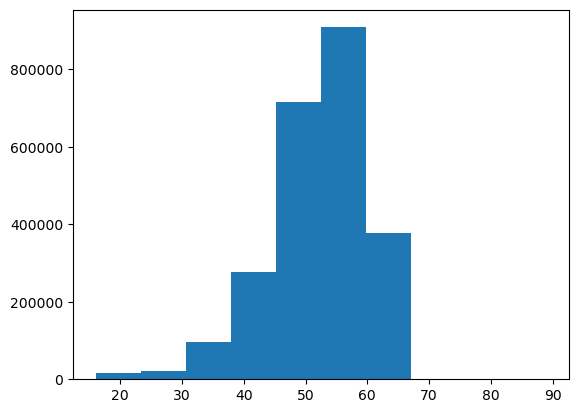

In [18]:

fig, axs= plt.subplots()
#fig.set_figwidth(15)
plt.hist(IWP,bins=np.logspace(-9,5,70))
axs.set_xscale('log')
plt.show()

fig, axs= plt.subplots()
#fig.set_figwidth(15)
axs.hist(TLWP,bins=np.logspace(-9,5,70))
axs.set_xscale('log')
plt.show()

fig, axs= plt.subplots()
#fig.set_figwidth(15)
axs.hist(CLWP,bins=np.logspace(-9,5,70))#,bins=np.logspace(-11,5,70))
axs.set_xscale('log')
plt.show()

fig, axs= plt.subplots()
#fig.set_figwidth(15)
axs.hist(IWV)#,bins=np.logspace(-11,5,70))
#axs.set_xscale('log')
plt.show()

In [15]:
ds_HAMP

<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables:
    AziAng                (time, frequency) float32 375MB ...
    ElAng                 (time, frequency) float32 375MB ...
    RF                    (time, frequency) float64 750MB ...
    TBs                   (time, frequency) float32 375MB ...
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    mask_amplifier_fault  (time, frequency) int64 750MB ...
    mask_sea_land         (time) int64 30MB ...
    plane_altitude        (time) float64 30MB ...
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV_myret             (time) float64 30MB nan nan nan nan ... nan nan nan
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0

In [14]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
ds_HAMP['IWV_myret']= (('time',), IWV)
#ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1.nc ')

In [23]:
iwv_v0=xr.open_dataset('/work/um0203/u301032/master_thesis/retrieved_data/IWV/Hamp_iwv_v1_alllevels.nc')

In [19]:
ds_HAMP=xr.open_dataset("/work/um0203/u301032/master_thesis/flight_data/halo_HAMP.nc")
ds_HAMP['IWV']= (('time',), IWV)
ds_HAMP['IWP']= (('time',), IWP)
ds_HAMP['TLWP']= (('time',), TLWP)
ds_HAMP['LWP']= (('time',), CLWP)

#make sure land values are NaN
##IWV=ds_HAMP.IWV.where(ds_HAMP.mask_sea_land==1, drop=True)
##LWP=ds_HAMP.LWP.where(ds_HAMP.mask_sea_land==1, drop=True)
##IWP=ds_HAMP.IWP.where(ds_HAMP.mask_sea_land==1, drop=True)

#snippet of code for amplifier mask 
##IWV=ds_HAMP.IWV.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))
##LWP=ds_HAMP.LWP.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))
##IWP=ds_HAMP.IWP.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))

##ds_HAMP['IWV']= IWV#(('time',), IWV)
##ds_HAMP['IWP']= IWP#(('time',), IWP)
##ds_HAMP['LWP']= LWP#(('time',), LWP)

In [ ]:
#### TODO Use amplifier mask and land sea mask for TBs prior to retrieval application.
#snippet of code for amplifier mask 
IWV=ds_HAMP.IWV.where(np.all(ds_HAMP.mask_amplifier_fault,axis=1))

#or:
  #ds_halo no sea please
da_masked = ds_halo.TBs.where(ds_halo.mask_sea_land, drop=True)

  # use amplifier fault mask and land sea mask
da_masked = da_masked.where(ds_halo.mask_amplifier_fault, drop=True)
  # add filtered data array to variable
ds_halo['TBs_filtered']= ( da_masked)


In [21]:
ds_HAMP
ds_HAMP.to_netcdf('/work/um0203/u301032/master_thesis/retrieved_data/HAMP_with_IWV_IWP_LWP_TLWP_v2.nc')

In [20]:
ds_HAMP


<xarray.Dataset> Size: 3GB
Dimensions:               (time: 3750412, frequency: 25)
Coordinates:
  * frequency             (frequency) float32 100B 22.24 23.04 ... 188.3 190.8
  * time                  (time) datetime64[ns] 30MB 2024-08-09T05:03:25 ... ...
Data variables: (12/15)
    AziAng                (time, frequency) float32 375MB ...
    ElAng                 (time, frequency) float32 375MB ...
    RF                    (time, frequency) float64 750MB ...
    TBs                   (time, frequency) float32 375MB ...
    lat                   (time) float64 30MB ...
    lon                   (time) float64 30MB ...
    ...                    ...
    plane_pitch           (time) float64 30MB ...
    plane_roll            (time) float64 30MB ...
    IWV                   (time) float64 30MB nan nan nan nan ... nan nan nan
    IWP                   (time) float64 30MB nan nan nan nan ... nan nan nan
    TLWP                  (time) float64 30MB nan nan nan nan ... nan nan nan
    LWP                   (time) float64 30MB nan nan nan nan ... nan nan nan
Attributes: (12/16)
    Host-PC_Software_Version:     V9.45
    Radiometer_Software_Version:  V9.45
    Radiometer_System:             RPG-HATPRO
    creator_email:                jakob.deutloff@uni-hamburg.de, lukas.kluft@...
    creator_name:                 Jakob Deutloff, Lukas Kluft, Clara Bayley
    featureType:                  trajectoryProfile
    ...                           ...
    platform:                     HALO
    project:                      ORCESTRA, PERCUSION
    references:                   10.5194/amt-12-1815-2019, 10.5194/essd-13-5...
    summary:                      This dataset contains measurements from the...
    title:                        Radiometer Data from the Halo Microwave Pac...
    version:                      1.0